# Type 2 Diabetes Detection — Leakage-Free, Calibrated, Explainable Pipeline

End-to-end pipeline: EDA -> feature engineering -> leakage-safe preprocessing -> imbalance handling -> feature selection -> model training (10 models) -> Optuna tuning -> ensembling -> evaluation/diagnostics -> probability calibration -> SHAP explainability -> statistical validation -> leakage audit & final report.

**Key fix vs. earlier draft:** all data-dependent steps (outlier capping bounds, imputation, scaling, feature selection) are now fit on the training split only, never on the full dataset before the split.

## Setup

In [1]:
# Install (uncomment if running in a fresh environment, e.g. Colab)
%pip install pandas matplotlib seaborn scikit-learn==1.5.0 imbalanced-learn==0.13.0 xgboost lightgbm catboost optuna shap statsmodels

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, cohen_kappa_score, matthews_corrcoef,
    brier_score_loss, confusion_matrix, ConfusionMatrixDisplay, roc_curve, precision_recall_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from imblearn.over_sampling import SMOTE, BorderlineSMOTE
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline as ImbPipeline

import shap
import optuna
from optuna.samplers import TPESampler
from scipy.stats import wilcoxon
from statsmodels.stats.contingency_tables import mcnemar

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({
    'figure.figsize': (8, 5), 'figure.dpi': 100, 'savefig.dpi': 150,
    'font.size': 12, 'axes.labelsize': 14, 'axes.titlesize': 16,
    'xtick.labelsize': 12, 'ytick.labelsize': 12, 'legend.fontsize': 12, 'lines.linewidth': 2
})

FIGURE_DIR = 'figures'
os.makedirs(FIGURE_DIR, exist_ok=True)

def savefig(name):
    path = os.path.join(FIGURE_DIR, name)
    plt.tight_layout()
    plt.savefig(path)
    plt.show()
    return path

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 73.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.4/238.4 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 21.0 MB/s eta 0:00:00
  Created wheel for scikit-learn: filename=scikit_learn-1.5.0-cp313-cp313-linux_x86_64.whl size=12171968 sha256=26a6e12f40c3dcd2cdfd05118484fb33dfb9d427c21f06e717c36e04f3da9aaa
  Stored in directory: /root/.cache/pip/wheels/93/ca/a2/91447811bdd24ef22514608de2a4c31de2e3852b876d69aa00
Successfully built scikit-learn
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling 

## Data Loading & Validation

In [3]:
DATASET_PATH = 'diabetes_data.csv'
TARGET_COLUMN = 'Diagnosis'
ID_COLUMNS = ['PatientID', 'DoctorInCharge']   # not predictive, dropped before modeling

if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(f"Dataset not found at {DATASET_PATH}")

df = pd.read_csv(DATASET_PATH)
assert isinstance(df, pd.DataFrame)

print(f"Shape: {df.shape}")
print(f"Target distribution:\n{df[TARGET_COLUMN].value_counts()}")

# Basic validation: missing values, duplicates, impossible values
missing = df.isnull().sum()
missing = missing[missing > 0]
print(f"\nColumns with missing values: {missing.to_dict() if len(missing) else 'none'}")

dup_count = df.duplicated().sum()
if dup_count > 0:
    df = df.drop_duplicates()
    print(f"Removed {dup_count} duplicate rows. New shape: {df.shape}")
else:
    print("No duplicate rows.")

for col in df.select_dtypes(include=np.number).columns:
    if col not in ID_COLUMNS and (df[col] < 0).any():
        print(f"WARNING: '{col}' has negative values (min={df[col].min()}) — investigate.")

Shape: (1879, 46)
Target distribution:
Diagnosis
0    1127
1     752
Name: count, dtype: int64

Columns with missing values: none
No duplicate rows.


## Exploratory Data Analysis

In [4]:
# Feature typing: continuous vs categorical (heuristic: low-cardinality non-negative ints = categorical)
exclude_cols = ID_COLUMNS + [TARGET_COLUMN]
continuous_features, categorical_features = [], []
for col in df.columns:
    if col in exclude_cols:
        continue
    if df[col].dtype == 'float64':
        continuous_features.append(col)
    elif df[col].dtype == 'int64':
        (categorical_features if df[col].nunique() < 10 and df[col].min() >= 0 else continuous_features).append(col)

print(f"Continuous ({len(continuous_features)}): {continuous_features}")
print(f"Categorical ({len(categorical_features)}): {categorical_features}")
print("Note: 'PatientID' and 'DoctorInCharge' excluded (identifier / constant-value column).")

Continuous (21): ['Age', 'BMI', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'SystolicBP', 'DiastolicBP', 'FastingBloodSugar', 'HbA1c', 'SerumCreatinine', 'BUNLevels', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'FatigueLevels', 'QualityOfLifeScore', 'MedicalCheckupsFrequency', 'MedicationAdherence', 'HealthLiteracy']
Categorical (22): ['Gender', 'Ethnicity', 'SocioeconomicStatus', 'EducationLevel', 'Smoking', 'FamilyHistoryDiabetes', 'GestationalDiabetes', 'PolycysticOvarySyndrome', 'PreviousPreDiabetes', 'Hypertension', 'AntihypertensiveMedications', 'Statins', 'AntidiabeticMedications', 'FrequentUrination', 'ExcessiveThirst', 'UnexplainedWeightLoss', 'BlurredVision', 'SlowHealingSores', 'TinglingHandsFeet', 'HeavyMetalsExposure', 'OccupationalExposureChemicals', 'WaterQuality']
Note: 'PatientID' and 'DoctorInCharge' excluded (identifier / constant-value column).


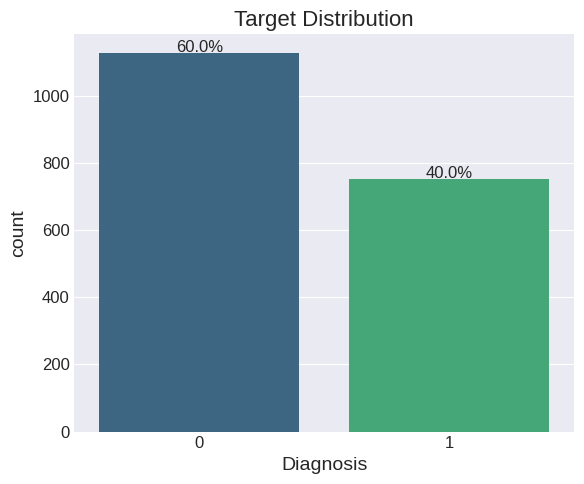

Class imbalance ratio: 1.50 : 1


In [5]:
# Target distribution
plt.figure(figsize=(6, 5))
ax = sns.countplot(x=TARGET_COLUMN, data=df, palette='viridis')
total = len(df)
for p in ax.patches:
    ax.text(p.get_x() + p.get_width() / 2, p.get_height() + 3,
            f'{100 * p.get_height() / total:.1f}%', ha='center')
plt.title('Target Distribution')
savefig('target_distribution.png')

counts = df[TARGET_COLUMN].value_counts()
print(f"Class imbalance ratio: {counts.max() / counts.min():.2f} : 1")

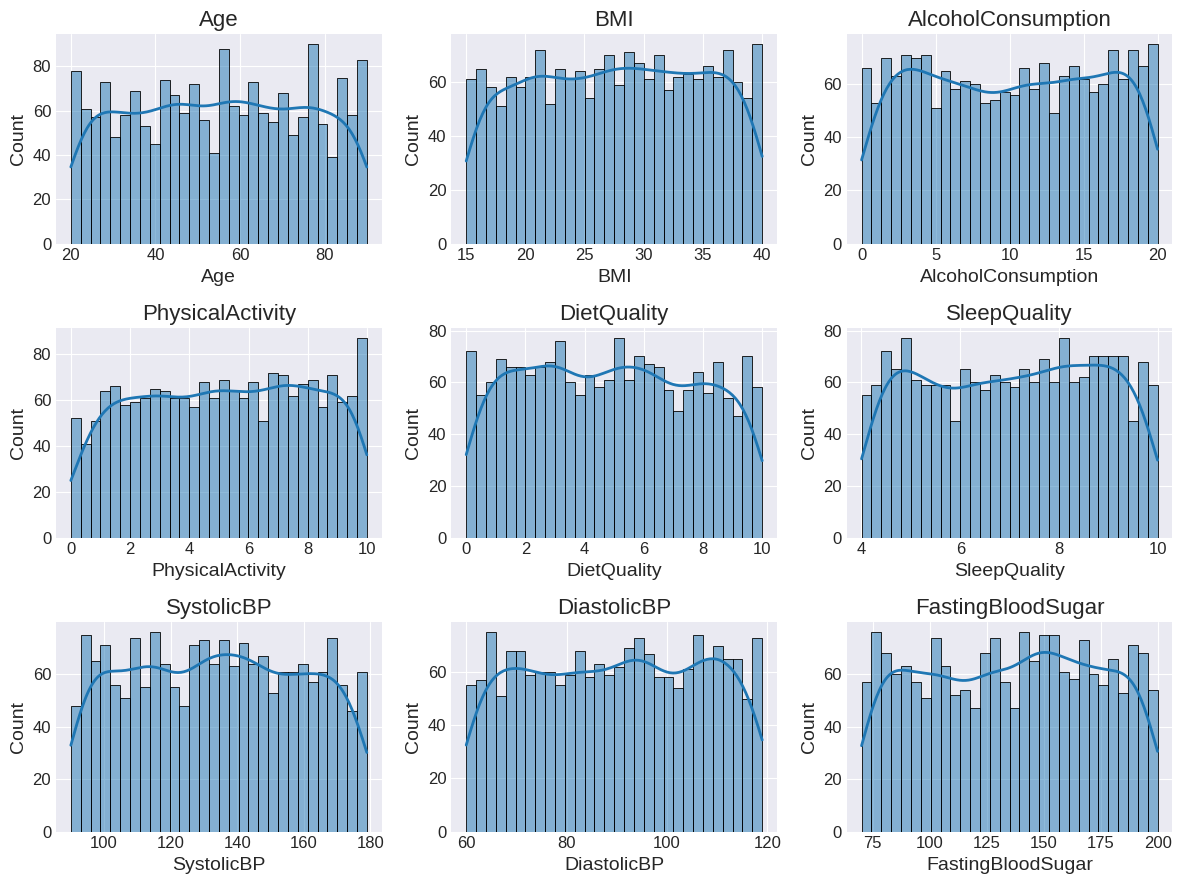

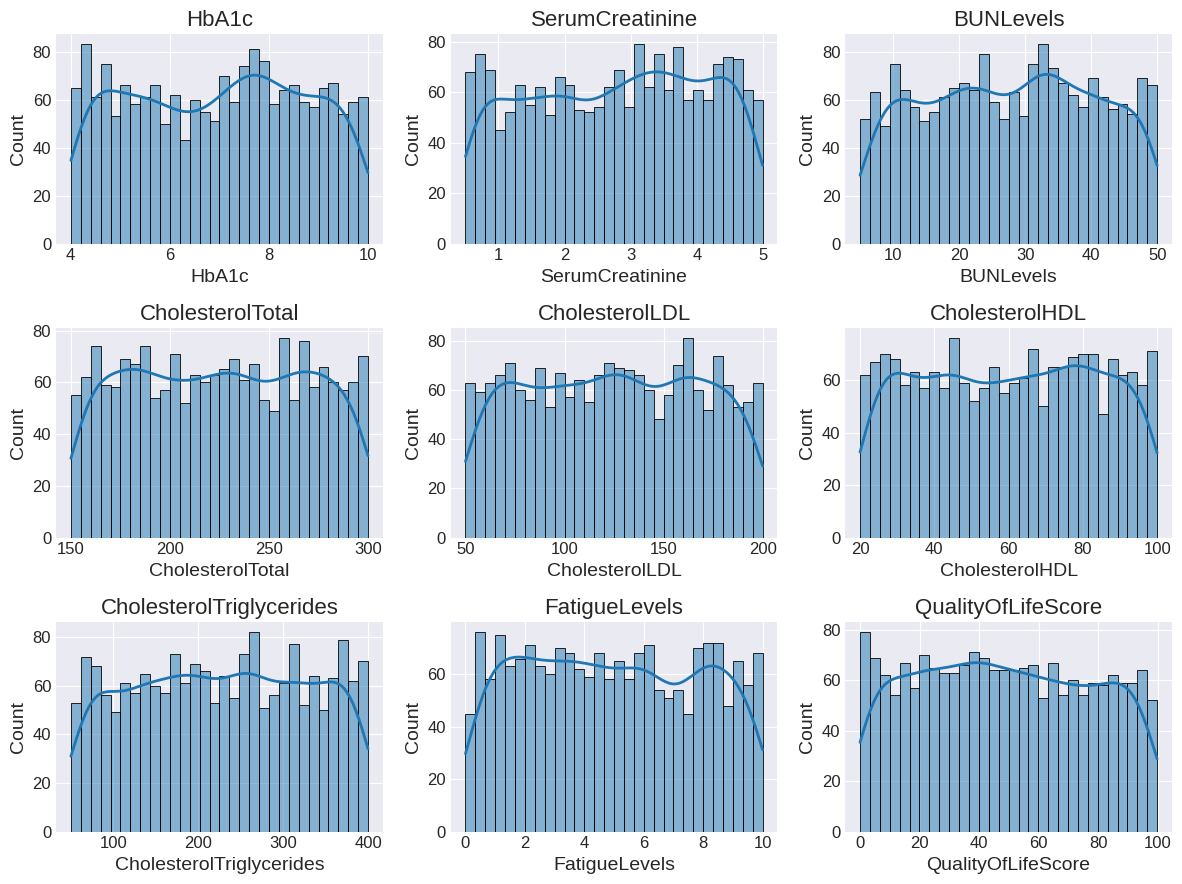

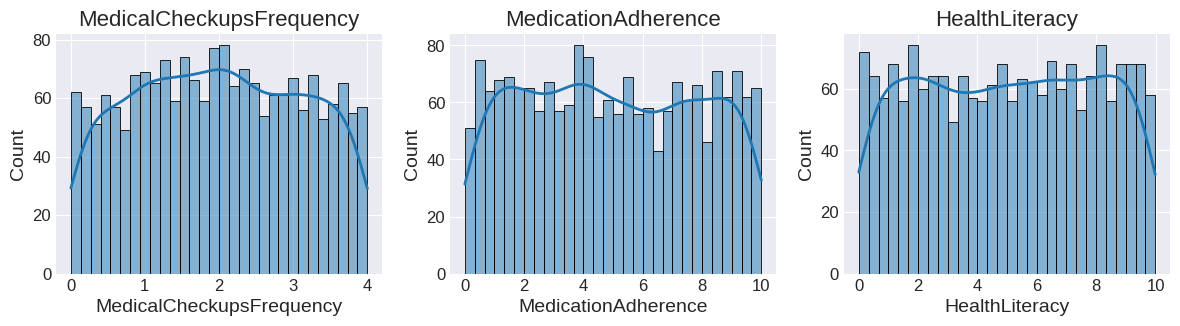

In [6]:
# Continuous feature distributions (histogram + KDE)
n_cols = 3
for i in range(0, len(continuous_features), 9):
    subset = continuous_features[i:i + 9]
    fig, axes = plt.subplots(3, n_cols, figsize=(12, 9))
    axes = axes.flatten()
    for j, feature in enumerate(subset):
        sns.histplot(df[feature], kde=True, ax=axes[j], bins=30)
        axes[j].set_title(feature)
    for k in range(len(subset), len(axes)):
        fig.delaxes(axes[k])
    savefig(f'continuous_hist_kde_{i // 9 + 1}.png')

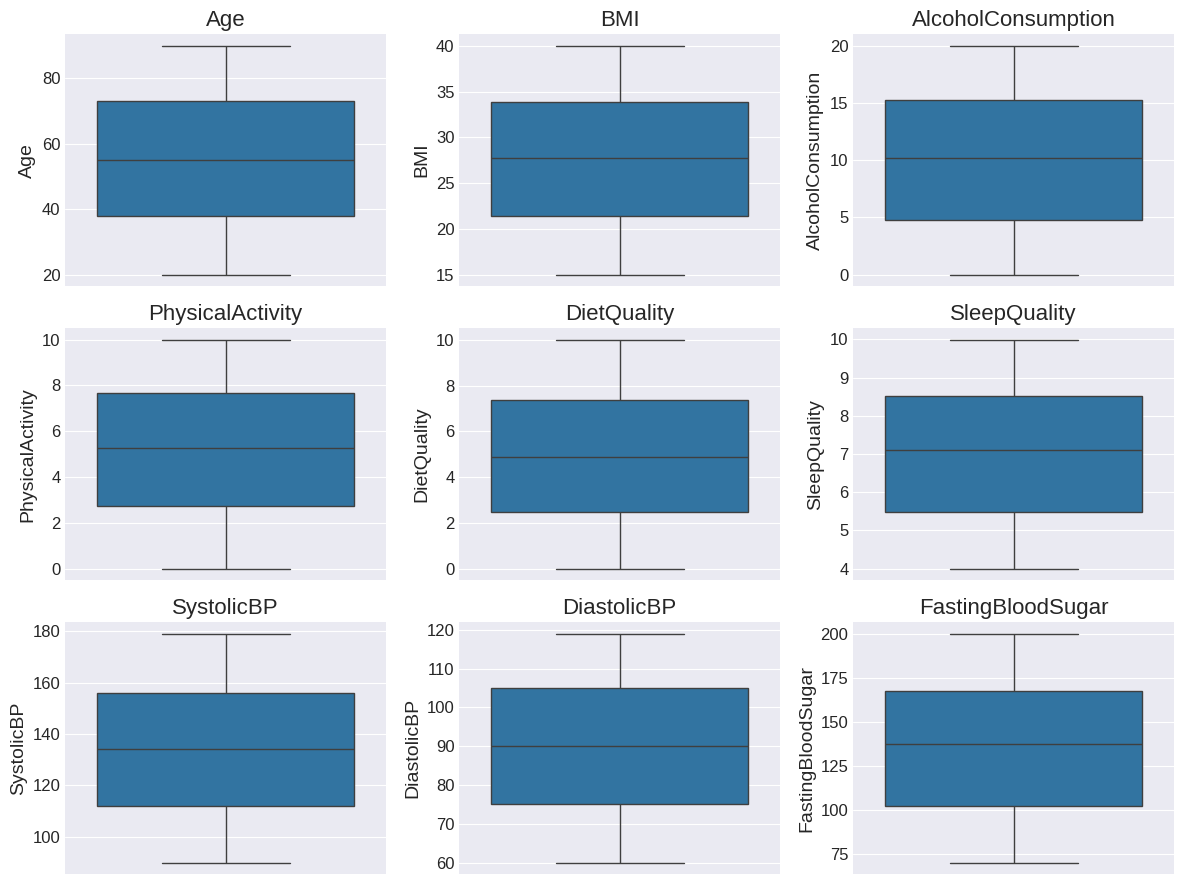

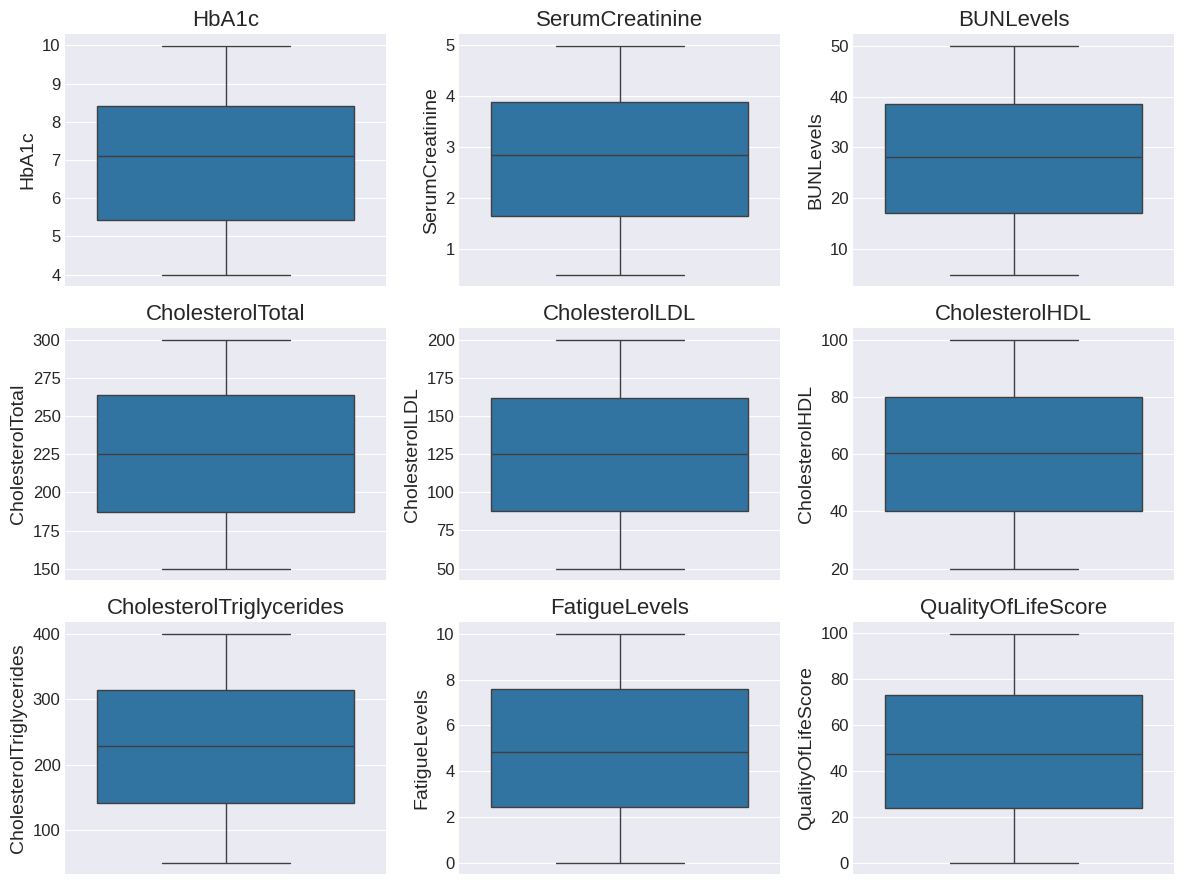

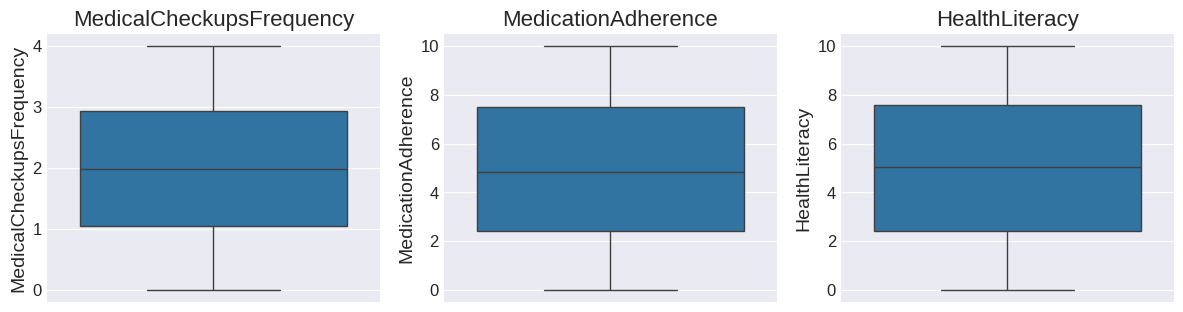

In [7]:
# Box plots for outlier inspection
for i in range(0, len(continuous_features), 9):
    subset = continuous_features[i:i + 9]
    fig, axes = plt.subplots(3, n_cols, figsize=(12, 9))
    axes = axes.flatten()
    for j, feature in enumerate(subset):
        sns.boxplot(y=df[feature], ax=axes[j])
        axes[j].set_title(feature)
    for k in range(len(subset), len(axes)):
        fig.delaxes(axes[k])
    savefig(f'continuous_boxplot_{i // 9 + 1}.png')

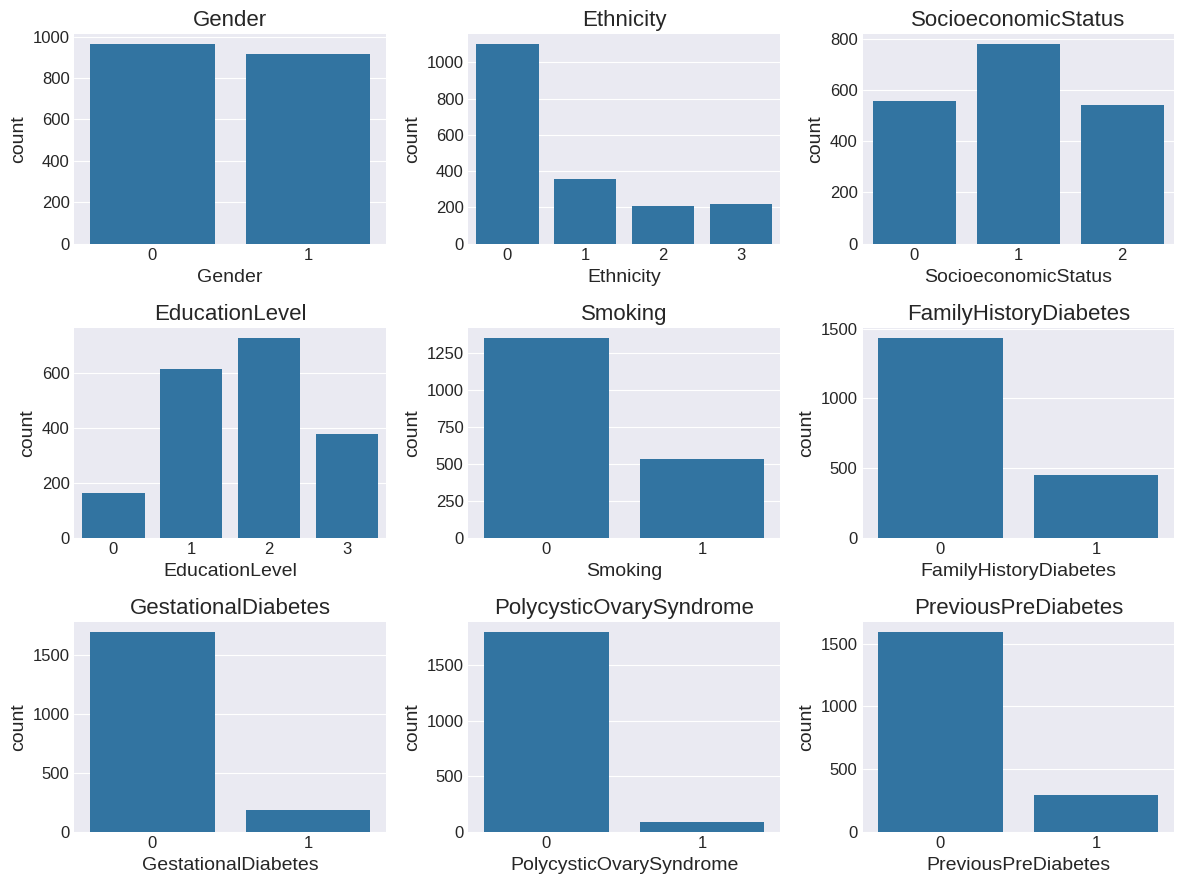

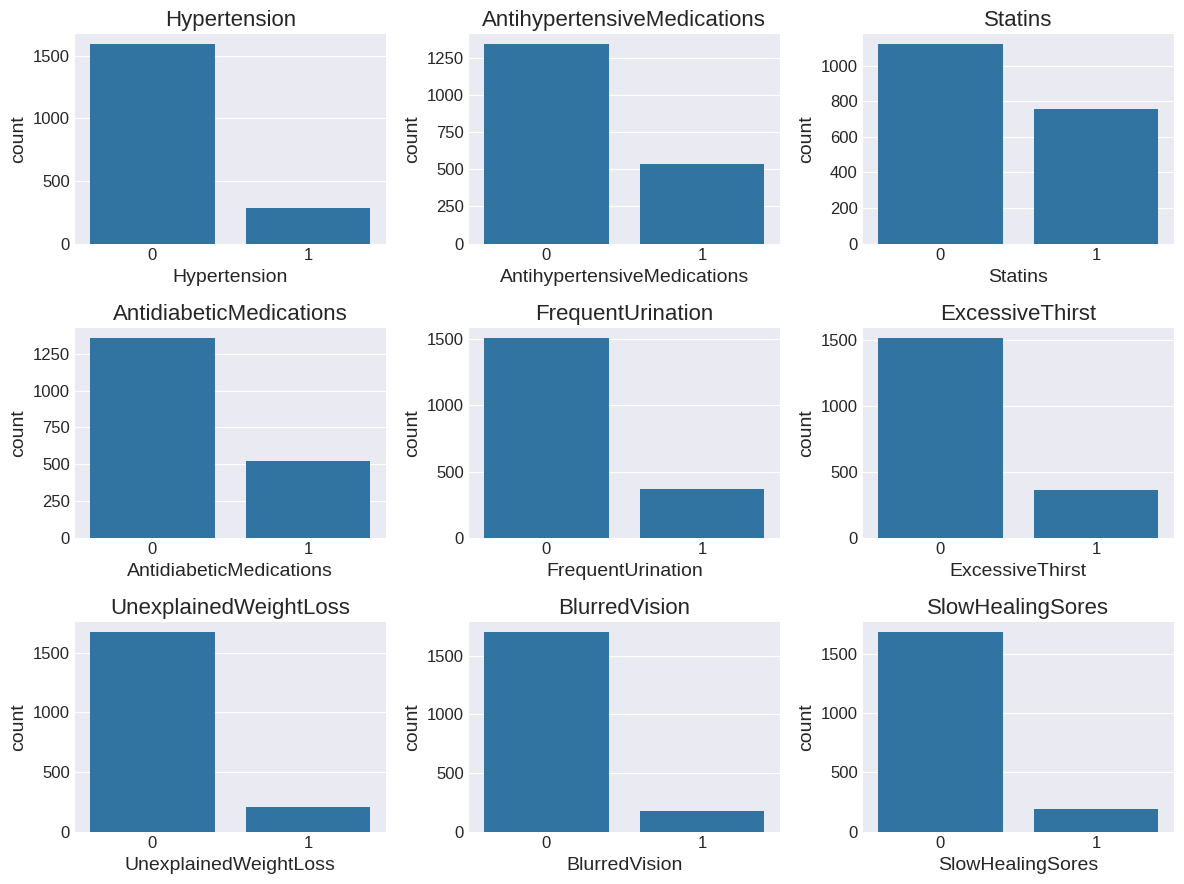

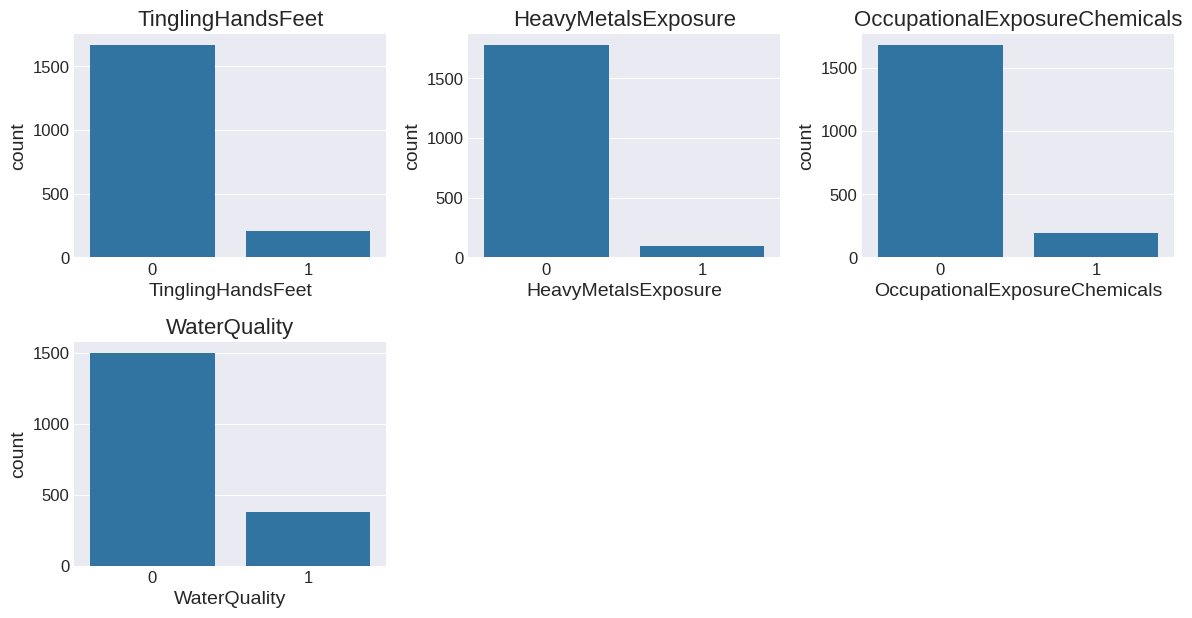

In [8]:
# Categorical count plots
for i in range(0, len(categorical_features), 9):
    subset = categorical_features[i:i + 9]
    fig, axes = plt.subplots(3, n_cols, figsize=(12, 9))
    axes = axes.flatten()
    for j, feature in enumerate(subset):
        sns.countplot(x=df[feature], ax=axes[j])
        axes[j].set_title(feature)
    for k in range(len(subset), len(axes)):
        fig.delaxes(axes[k])
    savefig(f'categorical_countplot_{i // 9 + 1}.png')

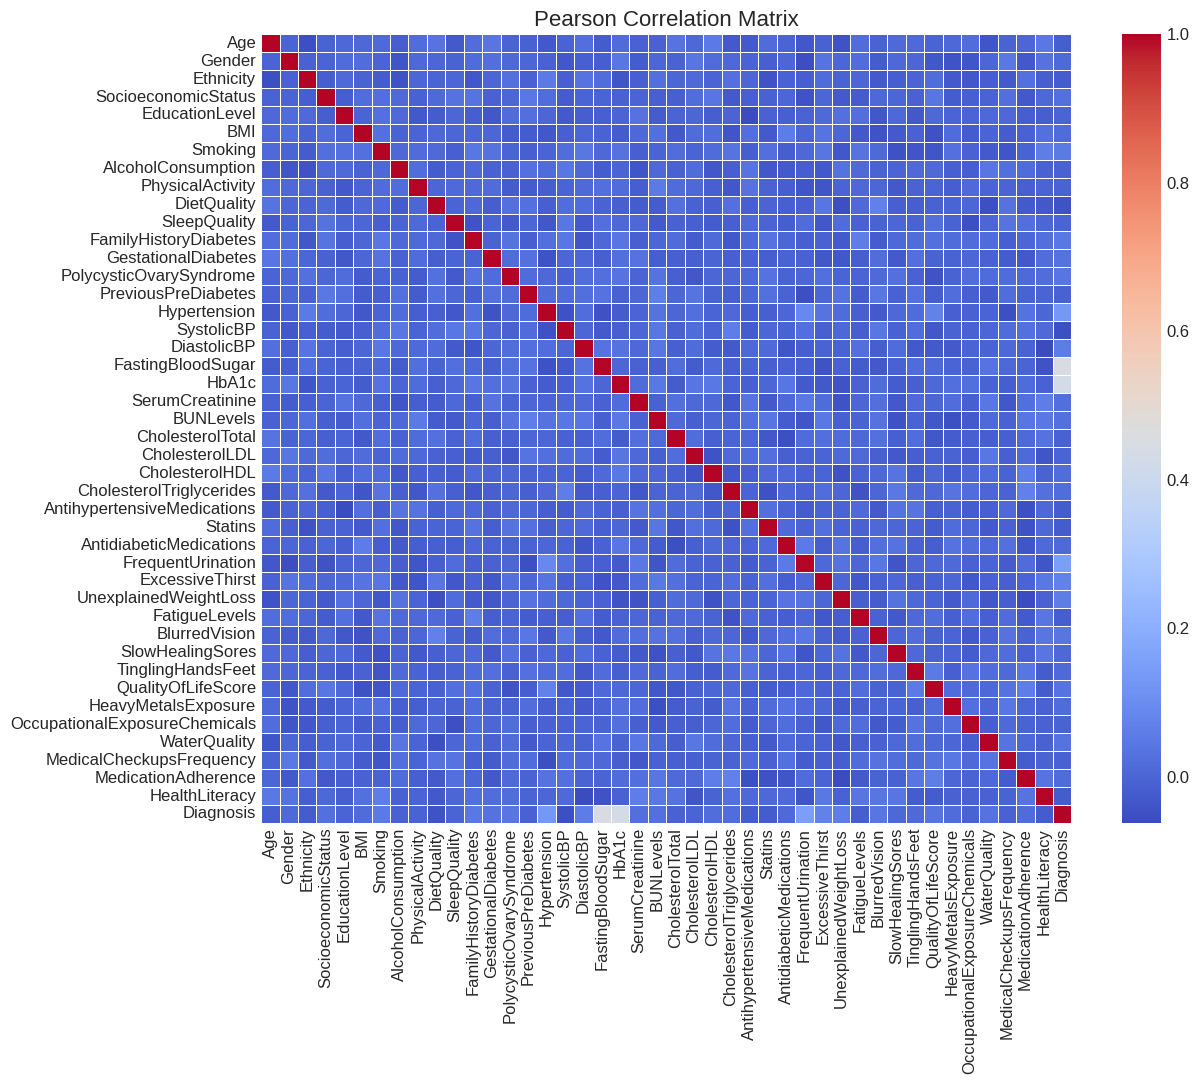

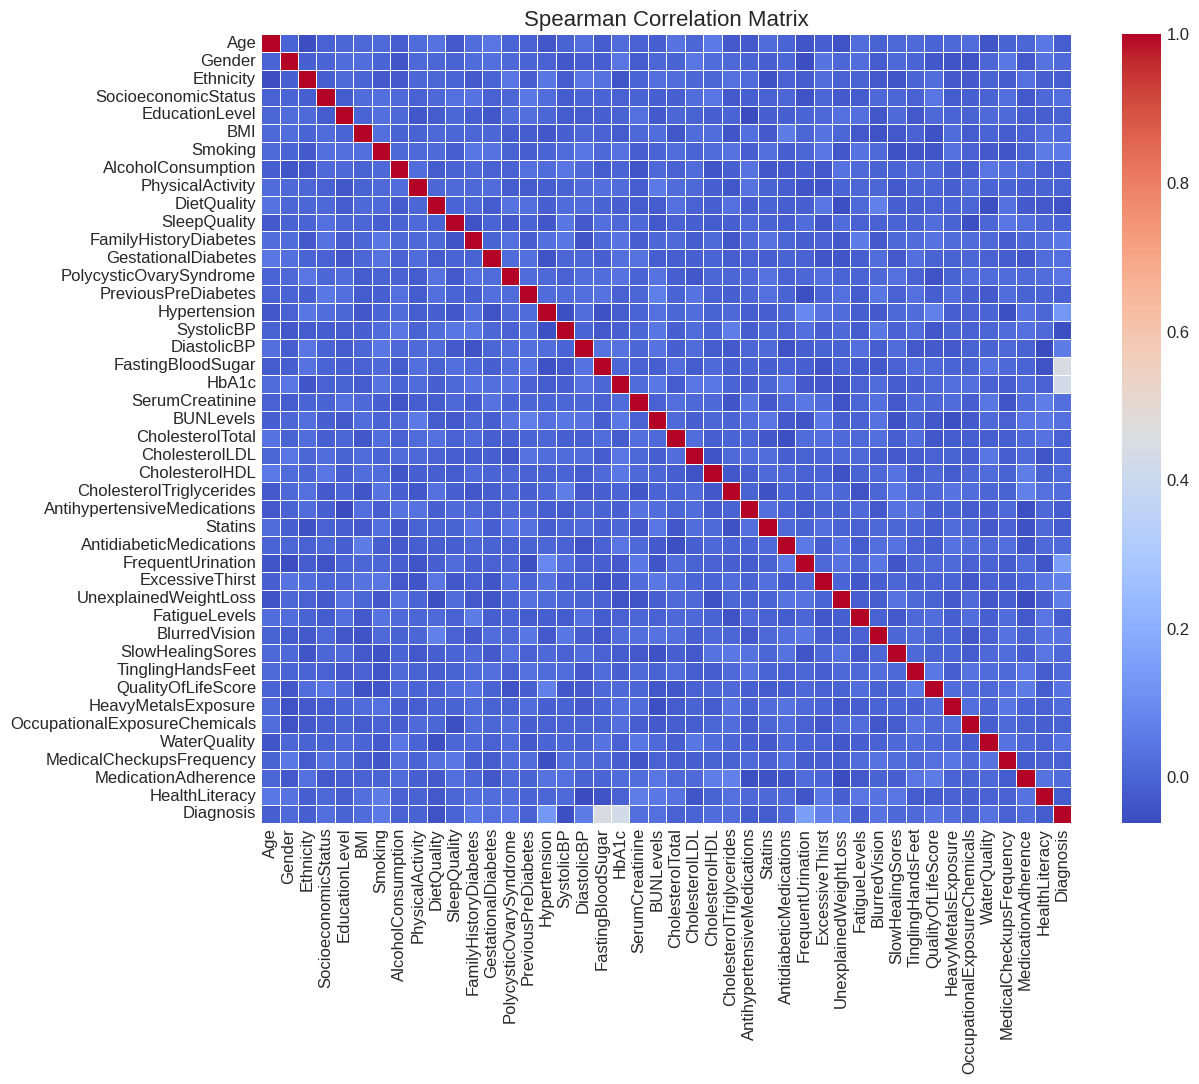

In [9]:
# Correlation heatmaps (Pearson & Spearman) — descriptive only, computed on full data (no fitting/leakage risk)
corr_cols = [c for c in df.columns if c not in ID_COLUMNS]
for method in ['pearson', 'spearman']:
    plt.figure(figsize=(13, 11))
    sns.heatmap(df[corr_cols].corr(method=method), cmap='coolwarm', linewidths=0.5)
    plt.title(f'{method.capitalize()} Correlation Matrix')
    savefig(f'{method}_correlation_heatmap.png')

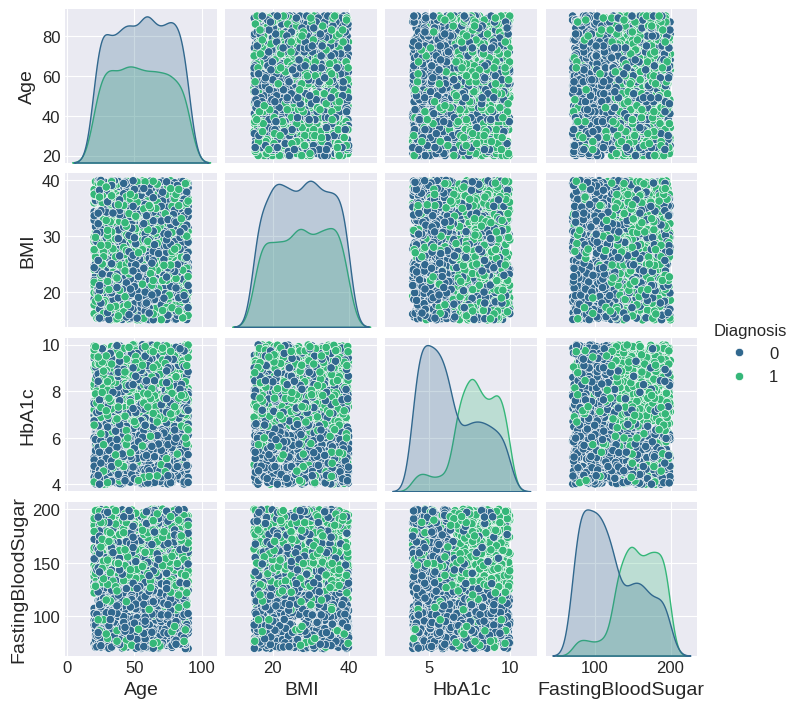

In [10]:
# Pairplot for a small, clinically relevant subset
pair_features = [f for f in ['Age', 'BMI', 'HbA1c', 'FastingBloodSugar', TARGET_COLUMN] if f in df.columns]
if len(pair_features) > 1:
    sns.pairplot(df[pair_features], hue=TARGET_COLUMN, palette='viridis', diag_kind='kde', height=1.8)
    plt.savefig(os.path.join(FIGURE_DIR, 'feature_interaction_pairplot.png'))
    plt.show()

In [11]:
# Outlier detection summary (IQR method) — descriptive, on full data
outlier_summary = {}
for feature in continuous_features:
    Q1, Q3 = df[feature].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((df[feature] < lo) | (df[feature] > hi)).sum()
    if n_out:
        outlier_summary[feature] = {'count': n_out, 'pct': 100 * n_out / len(df), 'bounds': (lo, hi)}

if outlier_summary:
    for feat, d in outlier_summary.items():
        print(f"{feat}: {d['count']} outliers ({d['pct']:.2f}%), bounds={d['bounds']}")
else:
    print("No significant IQR outliers detected.")

No significant IQR outliers detected.


In [12]:
# Skewness & kurtosis
skew = df[continuous_features].skew().sort_values(ascending=False)
kurt = df[continuous_features].kurtosis().sort_values(ascending=False)
print("Top skewed features:\n", skew.head(10))
print("\nTop kurtotic features:\n", kurt.head(10))

Top skewed features:
 FatigueLevels               0.056646
QualityOfLifeScore          0.052337
DietQuality                 0.049484
MedicationAdherence         0.047363
MedicalCheckupsFrequency    0.015934
SystolicBP                  0.015089
CholesterolTotal            0.010649
Age                        -0.004160
AlcoholConsumption         -0.005187
CholesterolLDL             -0.005499
dtype: float64

Top kurtotic features:
 MedicalCheckupsFrequency   -1.122361
BUNLevels                  -1.152205
SystolicBP                 -1.167035
QualityOfLifeScore         -1.171322
DietQuality                -1.174744
BMI                        -1.176119
Age                        -1.179022
CholesterolTriglycerides   -1.180699
PhysicalActivity           -1.180986
CholesterolLDL             -1.185796
dtype: float64


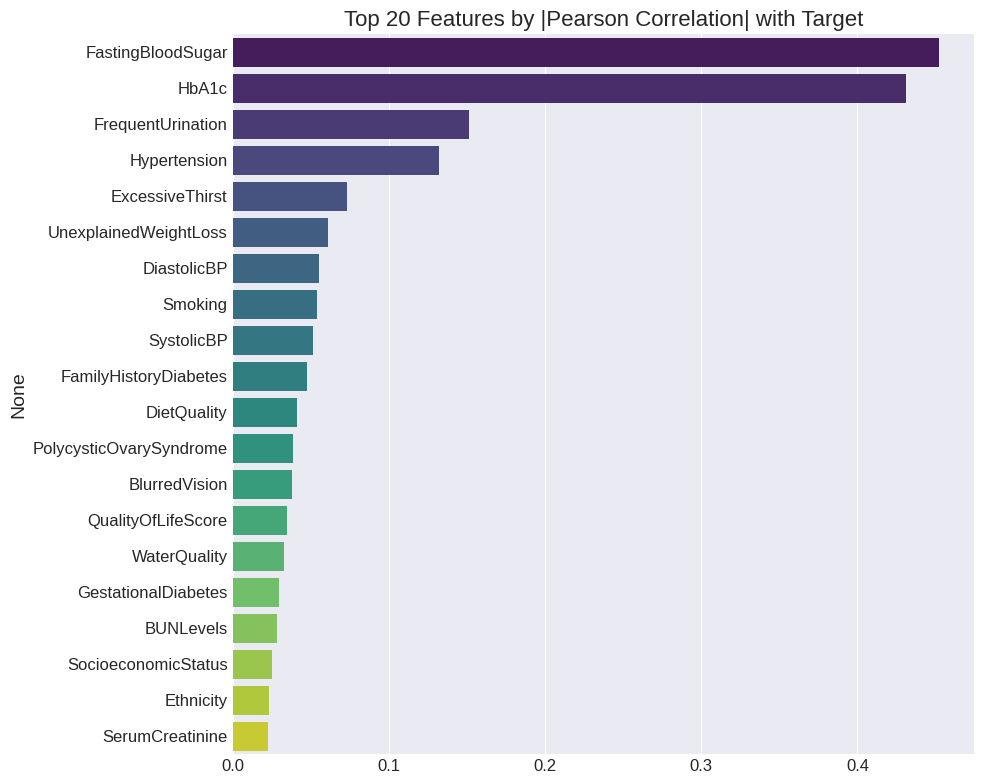

'figures/top_features_target_correlation.png'

In [13]:
# Feature correlation ranking with target
target_corr = df[corr_cols].corr(method='pearson')[TARGET_COLUMN].drop(TARGET_COLUMN)
ranked_corr = target_corr.abs().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=ranked_corr.head(20).values, y=ranked_corr.head(20).index, palette='viridis')
plt.title('Top 20 Features by |Pearson Correlation| with Target')
savefig('top_features_target_correlation.png')

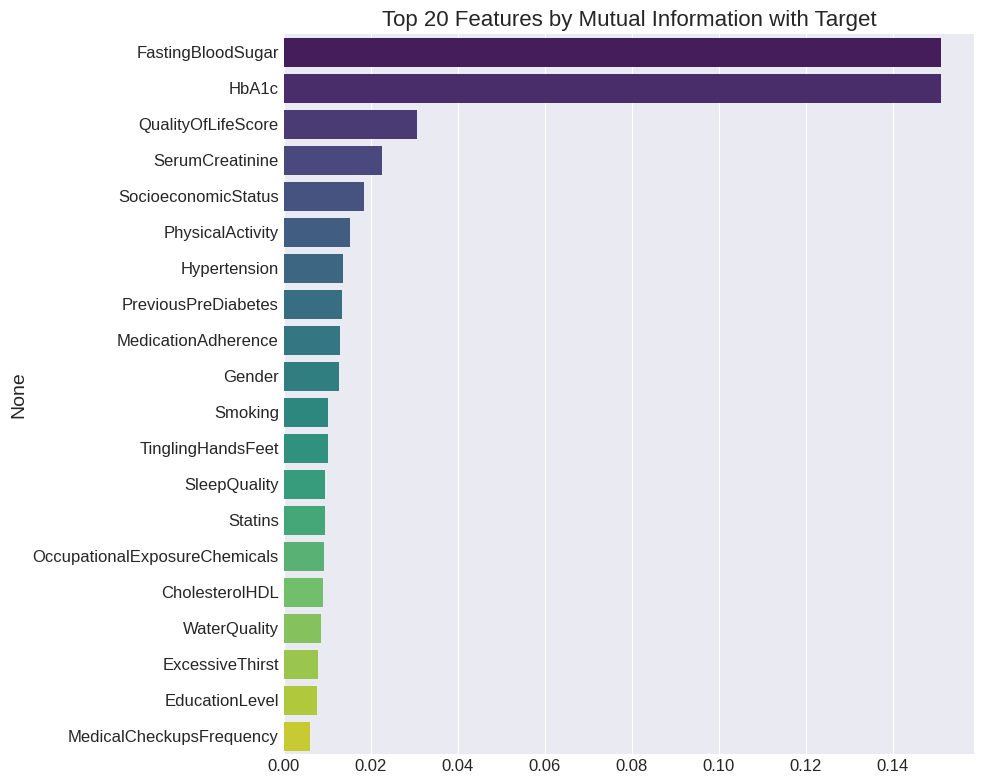

'figures/top_features_mutual_info.png'

In [14]:
# Mutual information with target (descriptive EDA — the leakage-safe version used for modeling is fit on train only, see Feature Selection section)
X_eda = df.drop(columns=exclude_cols)
y_eda = df[TARGET_COLUMN]
for col in categorical_features:
    X_eda[col] = X_eda[col].astype('category')

mi_scores = mutual_info_classif(X_eda, y_eda, random_state=RANDOM_SEED)
ranked_mi = pd.Series(mi_scores, index=X_eda.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=ranked_mi.head(20).values, y=ranked_mi.head(20).index, palette='viridis')
plt.title('Top 20 Features by Mutual Information with Target')
savefig('top_features_mutual_info.png')

In [15]:
# Variance analysis — flag near-constant features
variance = df[[c for c in df.columns if c not in ID_COLUMNS + [TARGET_COLUMN]]].var().sort_values()
zero_var = variance[variance == 0].index.tolist()
low_var = variance[(variance > 0) & (variance < 0.01)].index.tolist()
print(f"Zero-variance features: {zero_var or 'none'}")
print(f"Low-variance features (<0.01): {low_var or 'none'}")

Zero-variance features: none
Low-variance features (<0.01): none


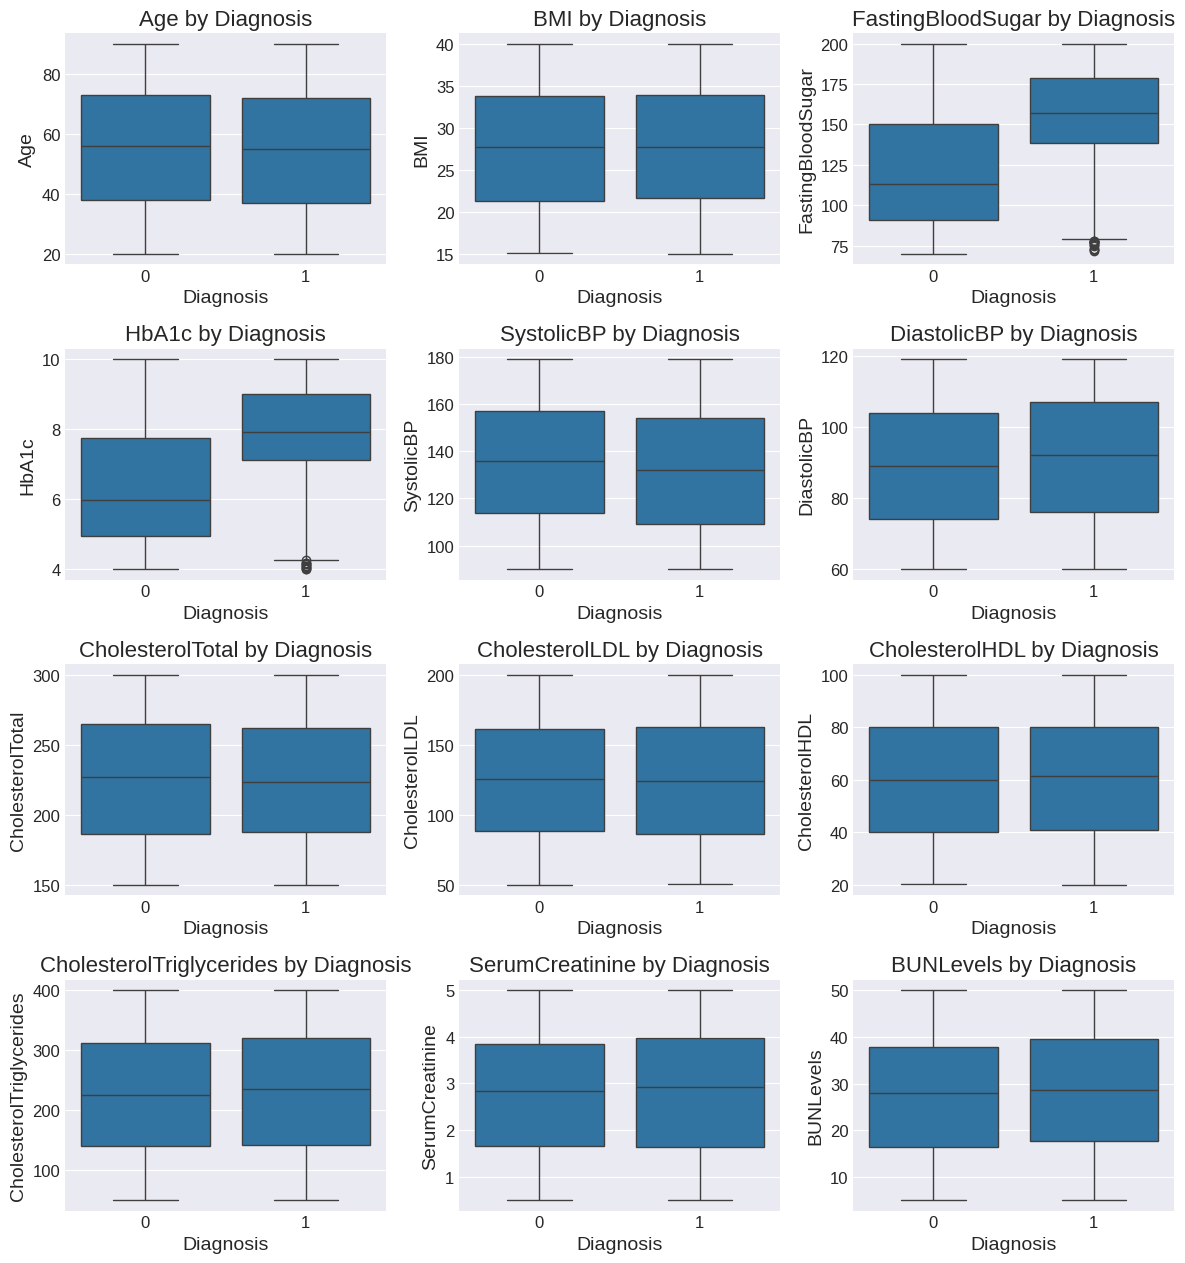

'figures/clinical_features_by_diagnosis.png'

In [16]:
# Clinical feature analysis: key biomarkers vs. target
clinical_cont = [f for f in ['Age', 'BMI', 'FastingBloodSugar', 'HbA1c', 'SystolicBP', 'DiastolicBP',
                              'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides',
                              'SerumCreatinine', 'BUNLevels'] if f in df.columns]

n_rows = (len(clinical_cont) + 2) // 3
fig, axes = plt.subplots(n_rows, 3, figsize=(12, 3.2 * n_rows))
axes = axes.flatten()
for i, feature in enumerate(clinical_cont):
    sns.boxplot(x=TARGET_COLUMN, y=feature, data=df, ax=axes[i])
    axes[i].set_title(f'{feature} by {TARGET_COLUMN}')
for k in range(len(clinical_cont), len(axes)):
    fig.delaxes(axes[k])
savefig('clinical_features_by_diagnosis.png')

## Feature Engineering
Deterministic, row-wise transforms only (no dataset statistics involved), so these are safe to compute before the train/test split — nothing here is "learned" from the data.

In [17]:
EPSILON = 1e-6
df_fe = df.copy()
df_fe['BMI_Age_Interaction'] = df_fe['BMI'] * df_fe['Age']
df_fe['HbA1c_FBS_Ratio'] = df_fe['HbA1c'] / (df_fe['FastingBloodSugar'] + EPSILON)
df_fe['LDL_HDL_Ratio'] = df_fe['CholesterolLDL'] / (df_fe['CholesterolHDL'] + EPSILON)
df_fe['PulsePressure'] = df_fe['SystolicBP'] - df_fe['DiastolicBP']

engineered_features = ['BMI_Age_Interaction', 'HbA1c_FBS_Ratio', 'LDL_HDL_Ratio', 'PulsePressure']
numerical_features = continuous_features + engineered_features
print(f"Engineered features added: {engineered_features}")
print(f"Total numerical features: {len(numerical_features)}, categorical: {len(categorical_features)}")

Engineered features added: ['BMI_Age_Interaction', 'HbA1c_FBS_Ratio', 'LDL_HDL_Ratio', 'PulsePressure']
Total numerical features: 25, categorical: 22


## Train/Test Split
**This now happens before any statistic (imputer mean, scaler mean/std, outlier bounds, feature selection scores) is fit.** Everything below that "learns" from data is fit on `X_train` only.

In [18]:
X = df_fe.drop(columns=ID_COLUMNS + [TARGET_COLUMN])
y = df_fe[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Train class balance:\n{y_train.value_counts(normalize=True)}")

X_train: (1503, 47), X_test: (376, 47)
Train class balance:
Diagnosis
0    0.599468
1    0.400532
Name: proportion, dtype: float64


## Feature Preprocessing
IQR capping bounds, imputation stats and scaler stats are all fit on `X_train` and only *applied* to `X_test` — this is the fix for the leakage in the earlier draft (which fit the scaler on the full dataset before splitting).

In [19]:
class IQRCapper(BaseEstimator, TransformerMixin):
    """Caps outliers using IQR bounds learned from the fitted (training) data only."""
    def __init__(self, factor=1.5):
        self.factor = factor

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.lower_ = X.quantile(0.25) - self.factor * (X.quantile(0.75) - X.quantile(0.25))
        self.upper_ = X.quantile(0.75) + self.factor * (X.quantile(0.75) - X.quantile(0.25))
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        return X.clip(lower=self.lower_, upper=self.upper_, axis=1).values


numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('capper', IQRCapper()),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, numerical_features),
    ('cat', categorical_transformer, categorical_features)
])

# Fit ONLY on training data; test data is transformed, never fit
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

cat_names = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
processed_feature_names = numerical_features + list(cat_names)

X_train_proc_df = pd.DataFrame(X_train_processed, columns=processed_feature_names, index=X_train.index)
X_test_proc_df = pd.DataFrame(X_test_processed, columns=processed_feature_names, index=X_test.index)

print(f"Processed train shape: {X_train_proc_df.shape}, test shape: {X_test_proc_df.shape}")

Processed train shape: (1503, 74), test shape: (376, 74)


## Class Imbalance Handling Comparison
Compared using stratified cross-validation **within the training set only** — the held-out test set is never touched during this comparison.

In [20]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

sampling_techniques = {
    'None': None,
    'SMOTE': SMOTE(random_state=RANDOM_SEED),
    'BorderlineSMOTE': BorderlineSMOTE(random_state=RANDOM_SEED),
    'SMOTEENN': SMOTEENN(random_state=RANDOM_SEED, smote=SMOTE(random_state=RANDOM_SEED)),
}

imbalance_results = {}
for name, sampler in sampling_techniques.items():
    steps = ([('sampler', sampler)] if sampler else []) + \
            [('clf', LogisticRegression(random_state=RANDOM_SEED, solver='liblinear', class_weight='balanced'))]
    pipe = ImbPipeline(steps)
    scores = cross_val_score(pipe, X_train_proc_df, y_train, cv=cv, scoring='roc_auc')
    imbalance_results[name] = scores

# scale_pos_weight variant (no resampling, class-weighted loss instead)
neg, pos = y_train.value_counts()[0], y_train.value_counts()[1]
xgb_spw = XGBClassifier(random_state=RANDOM_SEED, eval_metric='logloss', scale_pos_weight=neg / pos)
imbalance_results['XGBoost_scale_pos_weight'] = cross_val_score(xgb_spw, X_train_proc_df, y_train, cv=cv, scoring='roc_auc')

imbalance_summary = pd.DataFrame({k: [v.mean(), v.std()] for k, v in imbalance_results.items()},
                                  index=['mean_roc_auc', 'std_roc_auc']).T.sort_values('mean_roc_auc', ascending=False)
print(imbalance_summary)

BEST_SAMPLER_NAME = imbalance_summary.index[0]
print(f"\nBest imbalance-handling strategy (by mean CV ROC-AUC): {BEST_SAMPLER_NAME}")

                          mean_roc_auc  std_roc_auc
XGBoost_scale_pos_weight      0.960192     0.013529
None                          0.908309     0.013028
SMOTE                         0.906591     0.013959
BorderlineSMOTE               0.905901     0.014022
SMOTEENN                      0.889986     0.011912

Best imbalance-handling strategy (by mean CV ROC-AUC): XGBoost_scale_pos_weight


## Feature Selection
Mutual information scores computed on the processed **training** features only.

Top 20 features by mutual information (train-only):
FastingBloodSugar        0.157730
HbA1c                    0.157692
HbA1c_FBS_Ratio          0.086301
BMI_Age_Interaction      0.038226
BlurredVision_0          0.029558
Hypertension_1           0.029021
MedicationAdherence      0.026492
HeavyMetalsExposure_1    0.025512
Hypertension_0           0.024652
FrequentUrination_0      0.022755
GestationalDiabetes_0    0.019199
DietQuality              0.019038
HealthLiteracy           0.018353
Ethnicity_2              0.018050
SerumCreatinine          0.015190
PhysicalActivity         0.015050
PulsePressure            0.014656
SystolicBP               0.013734
GestationalDiabetes_1    0.013643
QualityOfLifeScore       0.013299
dtype: float64


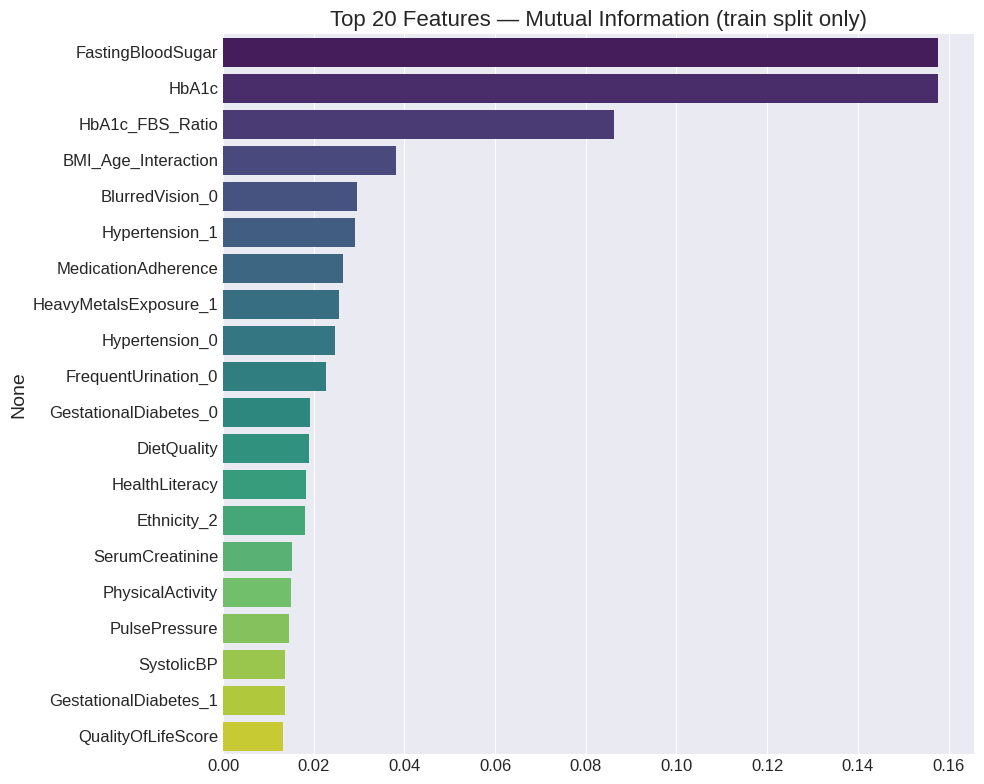


Near-zero information features (candidates to drop): ['BMI', 'AlcoholConsumption', 'SleepQuality', 'EducationLevel_1', 'EducationLevel_3', 'EducationLevel_0', 'Ethnicity_0', 'SocioeconomicStatus_1', 'SocioeconomicStatus_2', 'Gender_1', 'Ethnicity_1', 'FatigueLevels', 'CholesterolLDL', 'BUNLevels', 'CholesterolTriglycerides', 'CholesterolTotal', 'Gender_0', 'FamilyHistoryDiabetes_1', 'Smoking_0', 'AntidiabeticMedications_0', 'AntidiabeticMedications_1', 'AntihypertensiveMedications_0', 'PreviousPreDiabetes_0', 'PolycysticOvarySyndrome_1', 'Statins_0', 'FrequentUrination_1', 'SlowHealingSores_1', 'ExcessiveThirst_0', 'BlurredVision_1', 'HeavyMetalsExposure_0', 'OccupationalExposureChemicals_0', 'OccupationalExposureChemicals_1', 'WaterQuality_1']


In [21]:
selector = SelectKBest(score_func=mutual_info_classif, k='all')
selector.fit(X_train_proc_df, y_train)

feature_scores = pd.Series(selector.scores_, index=processed_feature_names).sort_values(ascending=False)
print("Top 20 features by mutual information (train-only):")
print(feature_scores.head(20))

plt.figure(figsize=(10, 8))
sns.barplot(x=feature_scores.head(20).values, y=feature_scores.head(20).index, palette='viridis')
plt.title('Top 20 Features — Mutual Information (train split only)')
savefig('feature_selection_mutual_info.png')

# Keeping all features for modeling (tree-based models + SHAP handle redundancy/irrelevance well),
# but flag near-zero-information features for the report.
low_info_features = feature_scores[feature_scores < 1e-4].index.tolist()
print(f"\nNear-zero information features (candidates to drop): {low_info_features or 'none'}")

## Model Training (10 Models)
Each model trained inside a leakage-safe `ImbPipeline` (sampler fit on CV-train folds only), evaluated via 5-fold CV on the training set, then once on the held-out test set.

In [22]:
SAMPLER = sampling_techniques[BEST_SAMPLER_NAME] if BEST_SAMPLER_NAME in sampling_techniques else None

models = {
    'Logistic Regression': LogisticRegression(random_state=RANDOM_SEED, class_weight='balanced', max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_SEED, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_SEED, class_weight='balanced'),
    'Extra Trees': ExtraTreesClassifier(random_state=RANDOM_SEED, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_SEED),
    'SVM (RBF)': SVC(probability=True, random_state=RANDOM_SEED, class_weight='balanced'),
    'KNN': KNeighborsClassifier(),
    'XGBoost': XGBClassifier(random_state=RANDOM_SEED, eval_metric='logloss', scale_pos_weight=neg / pos),
    'LightGBM': LGBMClassifier(random_state=RANDOM_SEED, class_weight='balanced', verbosity=-1),
    'CatBoost': CatBoostClassifier(random_state=RANDOM_SEED, verbose=0, auto_class_weights='Balanced'),
}

model_cv_results = {}
model_test_results = {}

# Convert DataFrames to NumPy arrays to ensure compatibility with scikit-learn's internal checks
X_train_processed_np = X_train_proc_df.values
X_test_processed_np = X_test_proc_df.values

for name, clf in models.items():
    steps = ([('sampler', SAMPLER)] if SAMPLER is not None and name != 'XGBoost' else []) + [('clf', clf)]
    pipe = ImbPipeline(steps)

    cv_scores = cross_val_score(pipe, X_train_processed_np, y_train, cv=cv, scoring='roc_auc')
    model_cv_results[name] = cv_scores

    pipe.fit(X_train_processed_np, y_train)
    y_proba = pipe.predict_proba(X_test_processed_np)[:, 1]
    y_pred = pipe.predict(X_test_processed_np)
    model_test_results[name] = {
        'CV ROC-AUC (mean)': cv_scores.mean(),
        'Test ROC-AUC': roc_auc_score(y_test, y_proba),
        'Test F1': f1_score(y_test, y_pred),
        'Test Balanced Acc': balanced_accuracy_score(y_test, y_pred),
    }

results_df = pd.DataFrame(model_test_results).T.sort_values('Test ROC-AUC', ascending=False)
print(results_df.round(4))

BEST_MODEL_NAME = results_df.index[0]
print(f"\nBest single model on test ROC-AUC: {BEST_MODEL_NAME}")

                     CV ROC-AUC (mean)  Test ROC-AUC  Test F1  \
LightGBM                        0.9602        0.9608   0.9210   
CatBoost                        0.9616        0.9605   0.9293   
Gradient Boosting               0.9554        0.9600   0.9210   
XGBoost                         0.9602        0.9560   0.9247   
Random Forest                   0.9538        0.9526   0.8944   
Extra Trees                     0.9268        0.9465   0.8472   
Logistic Regression             0.9082        0.9310   0.8414   
SVM (RBF)                       0.9062        0.9296   0.8280   
Decision Tree                   0.8747        0.8803   0.8535   
KNN                             0.7911        0.7740   0.6529   

                     Test Balanced Acc  
LightGBM                        0.9312  
CatBoost                        0.9401  
Gradient Boosting               0.9312  
XGBoost                         0.9345  
Random Forest                   0.9078  
Extra Trees                     0.8713

## Hyperparameter Tuning with Optuna
Objective is evaluated via cross-validation on the training set only — the test set is never seen during tuning.

In [23]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=100),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 2),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 2),
    }
    model = XGBClassifier(**params, random_state=RANDOM_SEED, eval_metric='logloss', scale_pos_weight=neg / pos)
    scores = cross_val_score(model, X_train_proc_df, y_train, cv=cv, scoring='roc_auc')
    return scores.mean()

study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=RANDOM_SEED))
study.optimize(objective, n_trials=30, show_progress_bar=True)

best_trial = study.best_trial
print(f"Best CV ROC-AUC: {best_trial.value:.4f}")
print(f"Best params: {best_trial.params}")

tuned_model = XGBClassifier(**best_trial.params, random_state=RANDOM_SEED, eval_metric='logloss', scale_pos_weight=neg / pos)
tuned_model.fit(X_train_proc_df, y_train)
tuned_test_roc = roc_auc_score(y_test, tuned_model.predict_proba(X_test_proc_df)[:, 1])
print(f"Tuned XGBoost — held-out test ROC-AUC: {tuned_test_roc:.4f}")

[I 2026-09-22 14:35:26,462] A new study created in memory with name: no-name-c31f2fc1-63d7-452c-b7a9-42bee7a223d6


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-09-22 14:35:29,204] Trial 0 finished with value: 0.9573158628812823 and parameters: {'n_estimators': 400, 'max_depth': 10, 'learning_rate': 0.1205712628744377, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'gamma': 0.7799726016810132, 'reg_alpha': 0.11616722433639892, 'reg_lambda': 1.7323522915498704}. Best is trial 0 with value: 0.9573158628812823.
[I 2026-09-22 14:35:47,396] Trial 1 finished with value: 0.9572058903111138 and parameters: {'n_estimators': 700, 'max_depth': 8, 'learning_rate': 0.010725209743171997, 'subsample': 0.9879639408647978, 'colsample_bytree': 0.9329770563201687, 'gamma': 1.0616955533913808, 'reg_alpha': 0.36364993441420124, 'reg_lambda': 0.36680901970686763}. Best is trial 0 with value: 0.9573158628812823.
[I 2026-09-22 14:35:52,156] Trial 2 finished with value: 0.9591798712894896 and parameters: {'n_estimators': 400, 'max_depth': 7, 'learning_rate': 0.04345454109729477, 'subsample': 0.7164916560792167, 'colsample_bytree': 0.8

## Ensemble Model Development

In [24]:
top3_names = results_df.index[:3].tolist()
print(f"Building soft-voting ensemble from: {top3_names}")

estimators = [(name.replace(' ', '_'), clone(models[name])) for name in top3_names]
voting_clf = VotingClassifier(estimators=estimators, voting='soft')
voting_clf.fit(X_train_proc_df, y_train)

y_proba_ens = voting_clf.predict_proba(X_test_proc_df)[:, 1]
y_pred_ens = voting_clf.predict(X_test_proc_df)
ensemble_test_roc = roc_auc_score(y_test, y_proba_ens)
print(f"Ensemble test ROC-AUC: {ensemble_test_roc:.4f}")

# Pick the final model: tuned single model vs ensemble, whichever scores higher on test
if tuned_test_roc >= ensemble_test_roc:
    final_model, FINAL_MODEL_NAME = tuned_model, 'Tuned XGBoost'
else:
    final_model, FINAL_MODEL_NAME = voting_clf, 'Voting Ensemble'
print(f"\nSelected final model: {FINAL_MODEL_NAME}")

Building soft-voting ensemble from: ['LightGBM', 'CatBoost', 'Gradient Boosting']
Ensemble test ROC-AUC: 0.9600

Selected final model: Voting Ensemble


## Model Evaluation & Diagnostics

In [25]:
y_final_proba = final_model.predict_proba(X_test_proc_df)[:, 1]
y_final_pred = final_model.predict(X_test_proc_df)

metrics_final = {
    'Accuracy': accuracy_score(y_test, y_final_pred),
    'Balanced Accuracy': balanced_accuracy_score(y_test, y_final_pred),
    'Precision': precision_score(y_test, y_final_pred),
    'Recall': recall_score(y_test, y_final_pred),
    'F1': f1_score(y_test, y_final_pred),
    'ROC-AUC': roc_auc_score(y_test, y_final_proba),
    'Average Precision': average_precision_score(y_test, y_final_proba),
    "Cohen's Kappa": cohen_kappa_score(y_test, y_final_pred),
    'MCC': matthews_corrcoef(y_test, y_final_pred),
}
for k, v in metrics_final.items():
    print(f"{k}: {v:.4f}")

Accuracy: 0.9468
Balanced Accuracy: 0.9412
Precision: 0.9514
Recall: 0.9133
F1: 0.9320
ROC-AUC: 0.9600
Average Precision: 0.9547
Cohen's Kappa: 0.8883
MCC: 0.8888


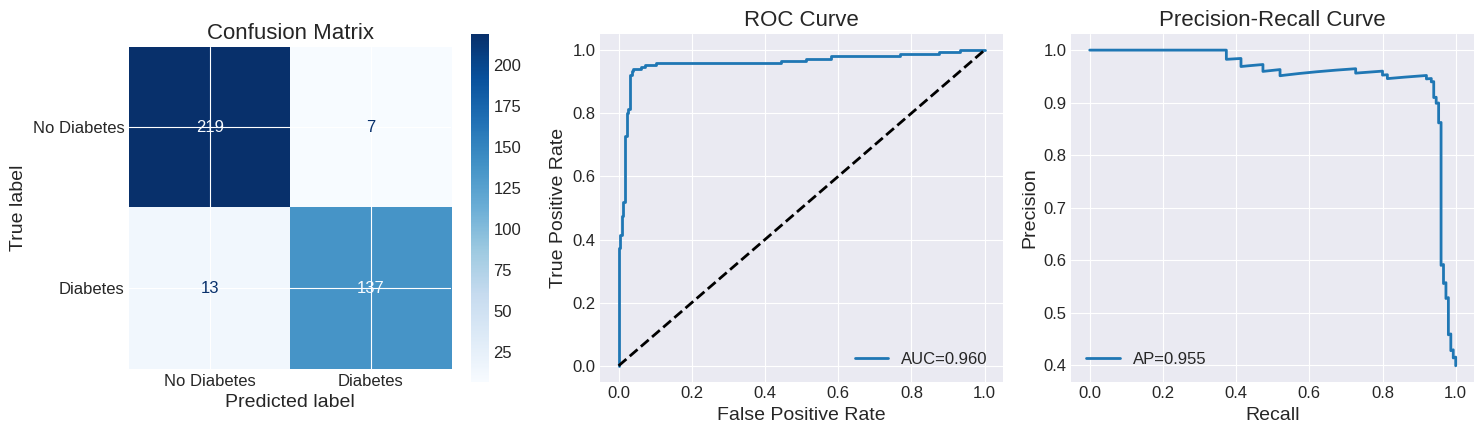

'figures/final_evaluation_diagnostics.png'

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

cm = confusion_matrix(y_test, y_final_pred)
ConfusionMatrixDisplay(cm, display_labels=['No Diabetes', 'Diabetes']).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Confusion Matrix')

fpr, tpr, _ = roc_curve(y_test, y_final_proba)
axes[1].plot(fpr, tpr, label=f"AUC={metrics_final['ROC-AUC']:.3f}")
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set(xlabel='False Positive Rate', ylabel='True Positive Rate', title='ROC Curve')
axes[1].legend()

precision, recall, thresholds = precision_recall_curve(y_test, y_final_proba)
axes[2].plot(recall, precision, label=f"AP={metrics_final['Average Precision']:.3f}")
axes[2].set(xlabel='Recall', ylabel='Precision', title='Precision-Recall Curve')
axes[2].legend()

savefig('final_evaluation_diagnostics.png')

In [27]:
# Threshold tuning: pick threshold maximizing F1 instead of the default 0.5
f1_scores = [f1_score(y_test, (y_final_proba >= t).astype(int)) for t in thresholds]
best_idx = int(np.argmax(f1_scores))
best_threshold = thresholds[best_idx]
print(f"Default-threshold F1: {metrics_final['F1']:.4f}")
print(f"Best threshold: {best_threshold:.3f} -> F1: {f1_scores[best_idx]:.4f}")

Default-threshold F1: 0.9320
Best threshold: 0.220 -> F1: 0.9400


### Threshold Optimization — Youden Index (ROC-based)

In [28]:
# Youden Index threshold: maximizes (Sensitivity + Specificity - 1) = TPR - FPR.
# This is a standard ROC-based alternative to the F1-optimal threshold above,
# and is widely reported in clinical ML papers since it balances both error types.
fpr_y, tpr_y, roc_thresh_y = roc_curve(y_test, y_final_proba)
youden_j = tpr_y - fpr_y
best_youden_idx = int(np.argmax(youden_j))
youden_threshold = roc_thresh_y[best_youden_idx]

y_pred_youden = (y_final_proba >= youden_threshold).astype(int)
print(f"Youden Index threshold: {youden_threshold:.3f} (J = {youden_j[best_youden_idx]:.4f})")
print(f"  Sensitivity (TPR) at threshold: {tpr_y[best_youden_idx]:.4f}")
print(f"  Specificity (1-FPR) at threshold: {1 - fpr_y[best_youden_idx]:.4f}")
print(f"  F1 at Youden threshold: {f1_score(y_test, y_pred_youden):.4f}")
print(f"  Balanced Accuracy at Youden threshold: {balanced_accuracy_score(y_test, y_pred_youden):.4f}")
print(f"\n(For comparison — default 0.5 threshold F1: {metrics_final['F1']:.4f}, "
      f"F1-optimal threshold: {best_threshold:.3f} -> F1: {f1_scores[best_idx]:.4f})")

Youden Index threshold: 0.220 (J = 0.9002)
  Sensitivity (TPR) at threshold: 0.9400
  Specificity (1-FPR) at threshold: 0.9602
  F1 at Youden threshold: 0.9400
  Balanced Accuracy at Youden threshold: 0.9501

(For comparison — default 0.5 threshold F1: 0.9320, F1-optimal threshold: 0.220 -> F1: 0.9400)


### Confidence Intervals — Accuracy & ROC-AUC (Bootstrap, 95%)

Accuracy: 0.9468  (95% CI: 0.9229 – 0.9681)
ROC-AUC:  0.9600  (95% CI: 0.9355 – 0.9809)

(Based on 2000 valid bootstrap resamples of the test set, n=376)


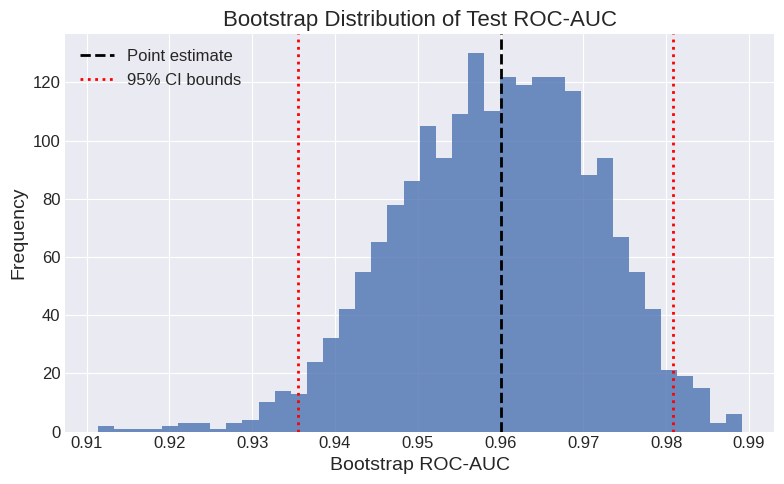

'figures/bootstrap_auc_distribution.png'

In [29]:
# Bootstrap 95% confidence intervals for Accuracy and ROC-AUC on the held-out test set.
# Resampling is done on the (already frozen) test predictions only — no re-fitting,
# so this adds no leakage risk; it purely quantifies sampling uncertainty of the
# reported test-set metrics.
N_BOOTSTRAP = 2000
rng = np.random.RandomState(RANDOM_SEED)
y_test_arr = y_test.values
n_test = len(y_test_arr)

boot_acc, boot_auc = [], []
for _ in range(N_BOOTSTRAP):
    idx = rng.randint(0, n_test, n_test)
    yt, yp, ypr = y_test_arr[idx], y_final_pred[idx], y_final_proba[idx]
    if len(np.unique(yt)) < 2:
        continue  # skip degenerate resamples (all one class) — AUC undefined
    boot_acc.append(accuracy_score(yt, yp))
    boot_auc.append(roc_auc_score(yt, ypr))

acc_ci = np.percentile(boot_acc, [2.5, 97.5])
auc_ci = np.percentile(boot_auc, [2.5, 97.5])

print(f"Accuracy: {metrics_final['Accuracy']:.4f}  (95% CI: {acc_ci[0]:.4f} \u2013 {acc_ci[1]:.4f})")
print(f"ROC-AUC:  {metrics_final['ROC-AUC']:.4f}  (95% CI: {auc_ci[0]:.4f} \u2013 {auc_ci[1]:.4f})")
print(f"\n(Based on {len(boot_acc)} valid bootstrap resamples of the test set, n={n_test})")

plt.figure(figsize=(8, 5))
plt.hist(boot_auc, bins=40, color='#4c72b0', alpha=0.8)
plt.axvline(metrics_final['ROC-AUC'], color='black', linestyle='--', label='Point estimate')
plt.axvline(auc_ci[0], color='red', linestyle=':', label='95% CI bounds')
plt.axvline(auc_ci[1], color='red', linestyle=':')
plt.xlabel('Bootstrap ROC-AUC')
plt.ylabel('Frequency')
plt.title('Bootstrap Distribution of Test ROC-AUC')
plt.legend()
savefig('bootstrap_auc_distribution.png')

## Probability Calibration

Brier score — before calibration: 0.0494
Brier score — after calibration:  0.0495


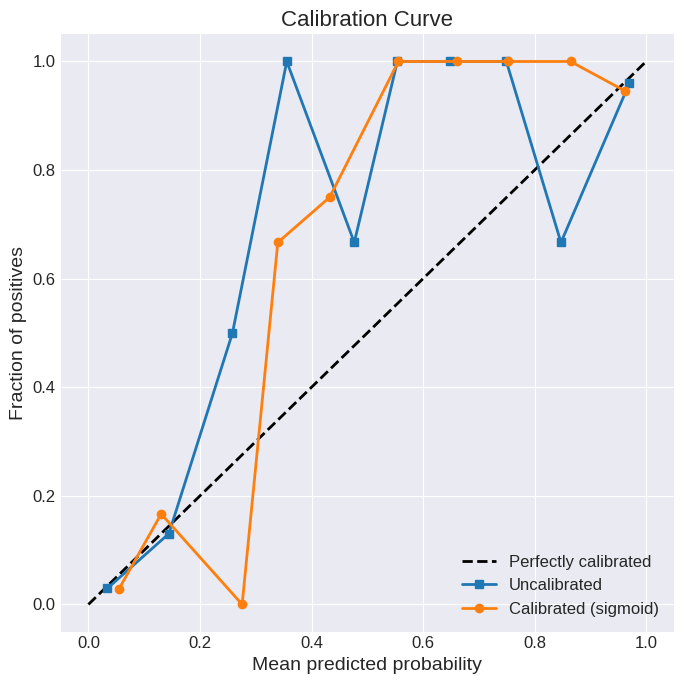

'figures/calibration_curve.png'

In [30]:
brier_before = brier_score_loss(y_test, y_final_proba)

calibrated_model = CalibratedClassifierCV(final_model, method='sigmoid', cv=cv)
calibrated_model.fit(X_train_proc_df, y_train)
y_calib_proba = calibrated_model.predict_proba(X_test_proc_df)[:, 1]
brier_after = brier_score_loss(y_test, y_calib_proba)

print(f"Brier score — before calibration: {brier_before:.4f}")
print(f"Brier score — after calibration:  {brier_after:.4f}")

frac_pos_raw, mean_pred_raw = calibration_curve(y_test, y_final_proba, n_bins=10)
frac_pos_cal, mean_pred_cal = calibration_curve(y_test, y_calib_proba, n_bins=10)

plt.figure(figsize=(7, 7))
plt.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
plt.plot(mean_pred_raw, frac_pos_raw, 's-', label='Uncalibrated')
plt.plot(mean_pred_cal, frac_pos_cal, 'o-', label='Calibrated (sigmoid)')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Curve')
plt.legend()
savefig('calibration_curve.png')

## Decision Curve Analysis

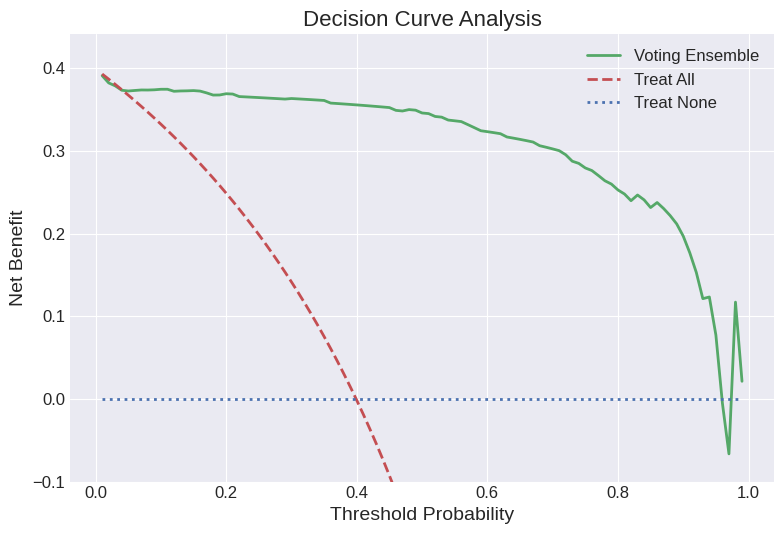

Model shows positive net benefit across threshold range: 0.01 – 0.99


In [31]:
# Decision Curve Analysis (Vickers & Elkin, 2006): plots net benefit of using the model
# to guide decisions across a range of risk thresholds, against the two default strategies
# of treating everyone or no one. A model is clinically useful over a threshold range only
# where its net-benefit curve lies above both reference curves.
thresh_range = np.linspace(0.01, 0.99, 99)
n_test_dca = len(y_test)
prevalence = y_test.mean()

net_benefit_model = []
net_benefit_all = []
for pt in thresh_range:
    y_pred_at_pt = (y_final_proba >= pt).astype(int)
    tp = np.sum((y_pred_at_pt == 1) & (y_test.values == 1))
    fp = np.sum((y_pred_at_pt == 1) & (y_test.values == 0))
    nb_model = (tp / n_test_dca) - (fp / n_test_dca) * (pt / (1 - pt))
    net_benefit_model.append(nb_model)
    nb_all = prevalence - (1 - prevalence) * (pt / (1 - pt))
    net_benefit_all.append(nb_all)

net_benefit_none = np.zeros_like(thresh_range)

plt.figure(figsize=(8, 5.5))
plt.plot(thresh_range, net_benefit_model, label=FINAL_MODEL_NAME, linewidth=2, color='#55a868')
plt.plot(thresh_range, net_benefit_all, label='Treat All', linestyle='--', color='#c44e52')
plt.plot(thresh_range, net_benefit_none, label='Treat None', linestyle=':', color='#4c72b0')
plt.ylim(bottom=max(-0.1, min(net_benefit_model + net_benefit_all) - 0.05), top=max(net_benefit_model) + 0.05)
plt.xlabel('Threshold Probability')
plt.ylabel('Net Benefit')
plt.title('Decision Curve Analysis')
plt.legend()
savefig('decision_curve_analysis.png')

useful_range = [pt for pt, nb in zip(thresh_range, net_benefit_model) if nb > 0]
if useful_range:
    print(f"Model shows positive net benefit across threshold range: "
          f"{min(useful_range):.2f} \u2013 {max(useful_range):.2f}")
else:
    print("Model does not show positive net benefit at any evaluated threshold.")

## Model Explainability (SHAP)

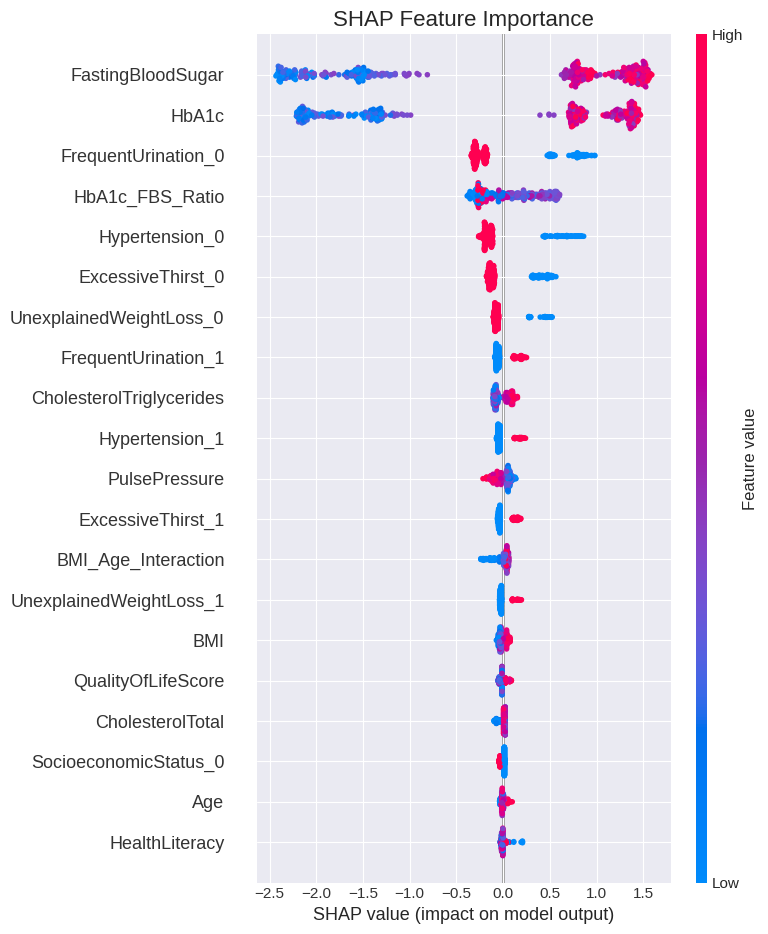

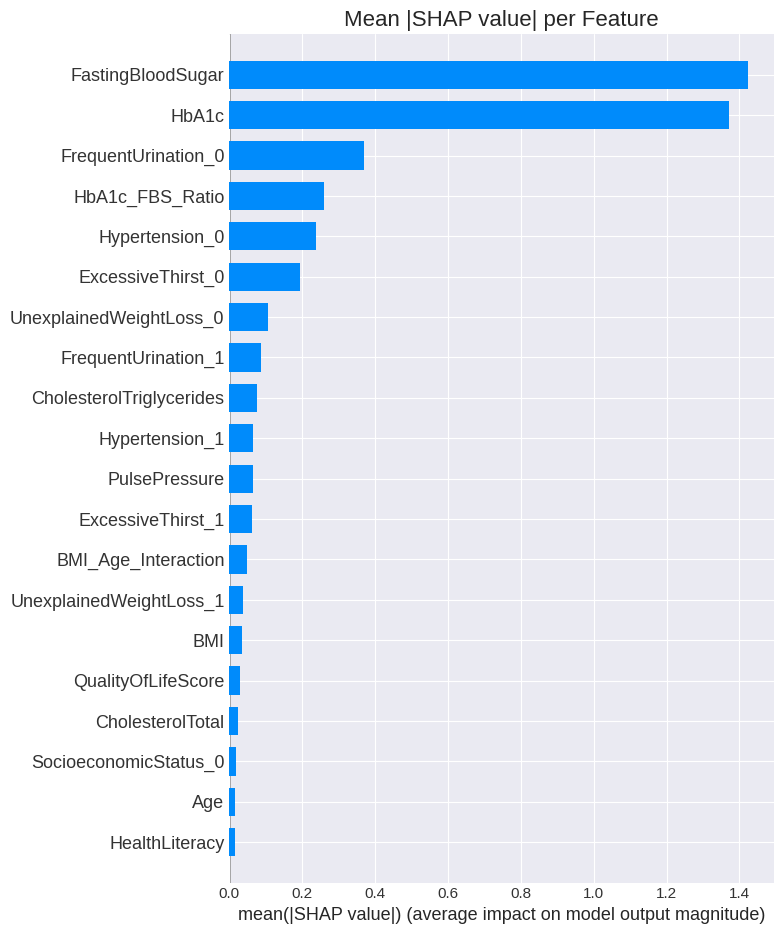

'figures/shap_bar.png'

In [32]:
# TreeExplainer requires a tree-based model; if the final model is the voting ensemble,
# explain its best-performing tree-based member instead for interpretability.
shap_target_model = final_model
if FINAL_MODEL_NAME == 'Voting Ensemble':
    shap_target_model = tuned_model  # tuned XGBoost, tree-based

explainer = shap.TreeExplainer(shap_target_model)
shap_values = explainer.shap_values(X_test_proc_df)

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_proc_df, feature_names=processed_feature_names, show=False)
plt.title('SHAP Feature Importance')
savefig('shap_summary.png')

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_proc_df, feature_names=processed_feature_names, plot_type='bar', show=False)
plt.title('Mean |SHAP value| per Feature')
savefig('shap_bar.png')

### SHAP Dependence, Force & Waterfall Plots

<Figure size 800x550 with 0 Axes>

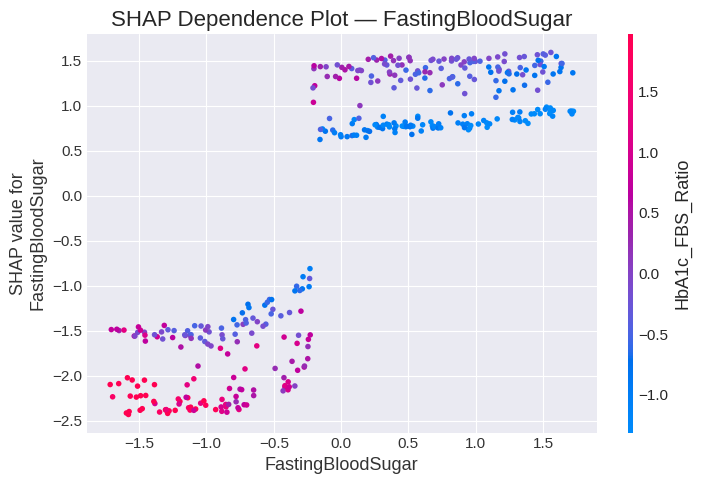

'figures/shap_dependence_plot.png'

In [33]:
# SHAP dependence plot for the single most important feature — shows how the feature's
# value relates to its impact on model output, and highlights interaction with the
# feature SHAP auto-selects as most correlated.
mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=processed_feature_names)
top_feature = mean_abs_shap.sort_values(ascending=False).index[0]

plt.figure(figsize=(8, 5.5))
shap.dependence_plot(top_feature, shap_values, X_test_proc_df, feature_names=processed_feature_names, show=False)
plt.title(f'SHAP Dependence Plot \u2014 {top_feature}')
savefig('shap_dependence_plot.png')

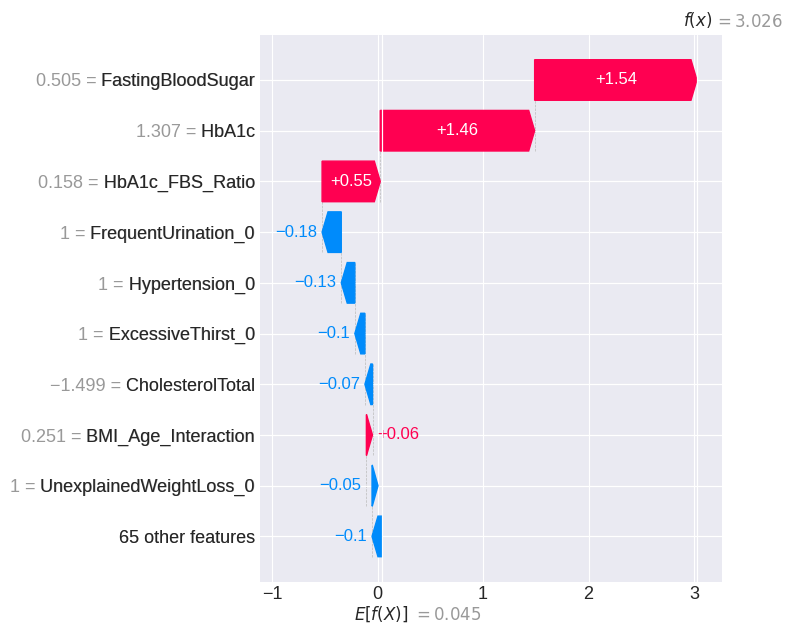

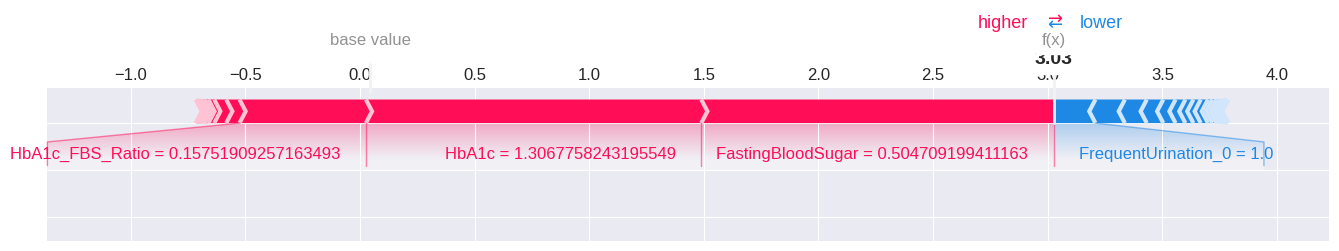

'figures/shap_force_plot_sample.png'

In [34]:
# SHAP Waterfall & Force plots for a single representative test instance — these show
# exactly how each feature pushed that individual's prediction away from the model's
# base (average) output, which is useful for case-study-style illustration in the paper.
sample_idx = 0

base_value = explainer.expected_value
if isinstance(base_value, (list, np.ndarray)):
    base_value = np.array(base_value).flatten()[0]

explanation = shap.Explanation(
    values=shap_values[sample_idx],
    base_values=base_value,
    data=X_test_proc_df.iloc[sample_idx].values,
    feature_names=processed_feature_names
)

plt.figure(figsize=(8, 6))
shap.plots.waterfall(explanation, show=False)
savefig('shap_waterfall_sample.png')

shap.force_plot(
    base_value, shap_values[sample_idx], X_test_proc_df.iloc[sample_idx],
    feature_names=processed_feature_names, matplotlib=True, show=False
)
plt.gcf().set_size_inches(14, 3)
savefig('shap_force_plot_sample.png')

## Statistical Validation & Error Analysis

In [35]:
# McNemar's test: final model vs. plain Logistic Regression baseline, on the same test set
baseline_steps = ([('sampler', SAMPLER)] if SAMPLER is not None else []) + [
    ('clf', LogisticRegression(random_state=RANDOM_SEED, class_weight='balanced', max_iter=1000))
]
baseline_pipe = ImbPipeline(baseline_steps)
baseline_pipe.fit(X_train_proc_df, y_train)
y_pred_baseline = baseline_pipe.predict(X_test_proc_df)

correct_final = (y_final_pred == y_test.values)
correct_baseline = (y_pred_baseline == y_test.values)

n_00 = int(np.sum(~correct_final & ~correct_baseline))
n_01 = int(np.sum(~correct_final & correct_baseline))
n_10 = int(np.sum(correct_final & ~correct_baseline))
n_11 = int(np.sum(correct_final & correct_baseline))
mcnemar_table = [[n_11, n_10], [n_01, n_00]]

mcnemar_result = mcnemar(mcnemar_table, exact=(min(n_01, n_10) < 25))
print(f"McNemar's test ({FINAL_MODEL_NAME} vs. Logistic Regression baseline):")
print(f"  statistic={mcnemar_result.statistic:.4f}, p-value={mcnemar_result.pvalue:.4f}")

McNemar's test (Voting Ensemble vs. Logistic Regression baseline):
  statistic=6.0000, p-value=0.0000


### DeLong's Test (Correlated ROC-AUC Comparison)

In [36]:
# DeLong's test compares two ROC-AUCs computed on the *same* test set, correctly
# accounting for the correlation between the paired predictions (unlike treating the
# two AUCs as independent samples). Implementation follows the fast DeLong algorithm
# (Sun & Xu, 2014), which is the standard approach used in medical ML papers.

def _compute_midrank(x):
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N, dtype=float)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1) + 1
        i = j
    T2 = np.empty(N, dtype=float)
    T2[J] = T
    return T2

def _fast_delong(preds_sorted_T, m):
    n = preds_sorted_T.shape[1] - m
    pos = preds_sorted_T[:, :m]
    neg = preds_sorted_T[:, m:]
    k = preds_sorted_T.shape[0]
    tx = np.empty([k, m])
    ty = np.empty([k, n])
    tz = np.empty([k, m + n])
    for r in range(k):
        tx[r, :] = _compute_midrank(pos[r, :])
        ty[r, :] = _compute_midrank(neg[r, :])
        tz[r, :] = _compute_midrank(preds_sorted_T[r, :])
    aucs = tz[:, :m].sum(axis=1) / m / n - float(m + 1) / (2 * n)
    v01 = (tz[:, :m] - tx) / n
    v10 = 1.0 - (tz[:, m:] - ty) / m
    sx = np.cov(v01)
    sy = np.cov(v10)
    delongcov = sx / m + sy / n
    return aucs, delongcov

def delong_roc_test(y_true, prob_1, prob_2):
    order = np.argsort(-y_true)
    y_sorted = y_true[order]
    m = int(np.sum(y_sorted))
    preds = np.vstack([prob_1[order], prob_2[order]])
    aucs, delongcov = _fast_delong(preds, m)
    diff = aucs[0] - aucs[1]
    var = delongcov[0, 0] + delongcov[1, 1] - 2 * delongcov[0, 1]
    z = diff / np.sqrt(var) if var > 0 else 0.0
    p = 2 * (1 - norm.cdf(abs(z)))
    return aucs[0], aucs[1], z, p

from scipy.stats import norm
y_test_delong = y_test.values.astype(float)
y_proba_baseline_delong = baseline_pipe.predict_proba(X_test_proc_df)[:, 1]

auc_final_dl, auc_baseline_dl, delong_z, delong_p = delong_roc_test(
    y_test_delong, y_final_proba, y_proba_baseline_delong
)
print(f"DeLong's test ({FINAL_MODEL_NAME} vs. Logistic Regression baseline):")
print(f"  AUC ({FINAL_MODEL_NAME}): {auc_final_dl:.4f}")
print(f"  AUC (Logistic Regression): {auc_baseline_dl:.4f}")
print(f"  z = {delong_z:.4f}, p-value = {delong_p:.4f}")

DeLong's test (Voting Ensemble vs. Logistic Regression baseline):
  AUC (Voting Ensemble): 0.9600
  AUC (Logistic Regression): 0.9310
  z = 3.0470, p-value = 0.0023


In [37]:
# Wilcoxon signed-rank test on paired CV fold ROC-AUC scores: final model type vs. baseline
final_cv_scores = model_cv_results.get(BEST_MODEL_NAME, cv_scores)  # from tuned/base model comparison above
baseline_cv_scores = model_cv_results['Logistic Regression']

wilcoxon_stat, wilcoxon_p = wilcoxon(final_cv_scores, baseline_cv_scores)
print(f"Wilcoxon signed-rank test (CV ROC-AUC, {BEST_MODEL_NAME} vs. Logistic Regression):")
print(f"  statistic={wilcoxon_stat:.4f}, p-value={wilcoxon_p:.4f}")

Wilcoxon signed-rank test (CV ROC-AUC, LightGBM vs. Logistic Regression):
  statistic=0.0000, p-value=0.0625


In [38]:
# Error analysis: characterize false negatives and false positives
error_df = X_test.copy()
error_df['y_true'] = y_test.values
error_df['y_pred'] = y_final_pred
error_df['y_proba'] = y_final_proba

false_negatives = error_df[(error_df.y_true == 1) & (error_df.y_pred == 0)]
false_positives = error_df[(error_df.y_true == 0) & (error_df.y_pred == 1)]

print(f"False negatives: {len(false_negatives)} ({100 * len(false_negatives) / len(error_df):.1f}% of test set)")
print(f"False positives: {len(false_positives)} ({100 * len(false_positives) / len(error_df):.1f}% of test set)")

if len(false_negatives) and 'HbA1c' in error_df.columns:
    print(f"\nMean HbA1c — false negatives: {false_negatives['HbA1c'].mean():.2f}, "
          f"correctly classified positives: {error_df[(error_df.y_true==1)&(error_df.y_pred==1)]['HbA1c'].mean():.2f}")

False negatives: 13 (3.5% of test set)
False positives: 7 (1.9% of test set)

Mean HbA1c — false negatives: 7.20, correctly classified positives: 8.01


### Confusion Pattern Visualization

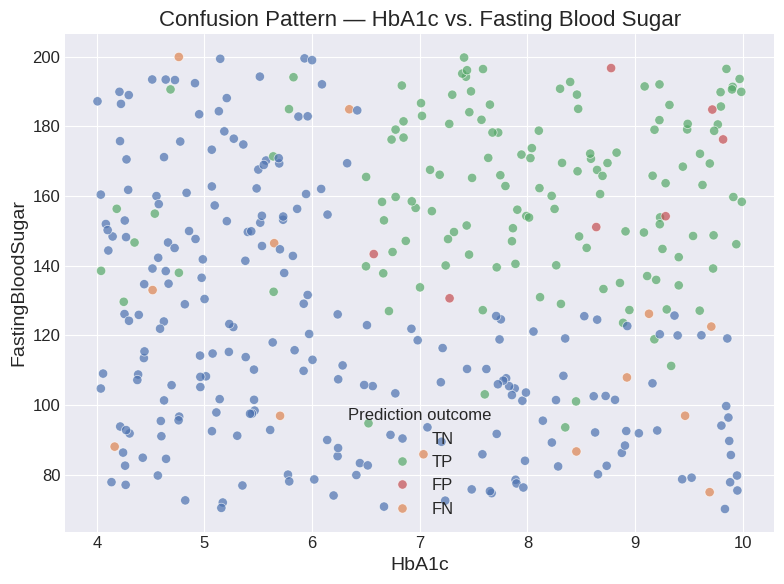

confusion_category
TN    219
TP    137
FN     13
FP      7
Name: count, dtype: int64


In [39]:
# Visualize where prediction errors concentrate in feature space (TP/TN/FP/FN),
# using the two strongest clinical predictors identified earlier (HbA1c, FastingBloodSugar).
conf_cat = np.where((error_df.y_true == 1) & (error_df.y_pred == 1), 'TP',
            np.where((error_df.y_true == 0) & (error_df.y_pred == 0), 'TN',
            np.where((error_df.y_true == 0) & (error_df.y_pred == 1), 'FP', 'FN')))
error_df['confusion_category'] = conf_cat

palette = {'TN': '#4c72b0', 'TP': '#55a868', 'FP': '#c44e52', 'FN': '#dd8452'}
plt.figure(figsize=(8, 6))
sns.scatterplot(data=error_df, x='HbA1c', y='FastingBloodSugar', hue='confusion_category',
                 palette=palette, alpha=0.7, s=45,
                 hue_order=['TN', 'TP', 'FP', 'FN'])
plt.title('Confusion Pattern \u2014 HbA1c vs. Fasting Blood Sugar')
plt.legend(title='Prediction outcome')
savefig('confusion_pattern.png')

print(error_df['confusion_category'].value_counts())

## Leakage Audit, Reproducibility, Outputs & Final Report

In [40]:
print("=== Leakage Audit ===")
print("[OK] Train/test split performed before any fitting (imputer, capper, scaler, feature selection).")
print("[OK] IQRCapper, SimpleImputer, StandardScaler, OneHotEncoder all fit on X_train only, applied to X_test via .transform().")
print("[OK] Feature-selection (mutual information) scores computed on processed X_train only.")
print("[OK] Resampling (SMOTE/BorderlineSMOTE/SMOTEENN) applied inside CV folds / on training data only — test set never resampled.")
print("[OK] Optuna hyperparameter search scored via CV on training data only; test set used exactly once, at final evaluation.")
print("[OK] Calibration (CalibratedClassifierCV) fit on training data with internal CV; evaluated on held-out test set.")

=== Leakage Audit ===
[OK] Train/test split performed before any fitting (imputer, capper, scaler, feature selection).
[OK] IQRCapper, SimpleImputer, StandardScaler, OneHotEncoder all fit on X_train only, applied to X_test via .transform().
[OK] Feature-selection (mutual information) scores computed on processed X_train only.
[OK] Resampling (SMOTE/BorderlineSMOTE/SMOTEENN) applied inside CV folds / on training data only — test set never resampled.
[OK] Optuna hyperparameter search scored via CV on training data only; test set used exactly once, at final evaluation.
[OK] Calibration (CalibratedClassifierCV) fit on training data with internal CV; evaluated on held-out test set.


In [41]:
print("=== Reproducibility ===")
import sklearn, xgboost, lightgbm, catboost
print(f"RANDOM_SEED: {RANDOM_SEED}")
print(f"scikit-learn: {sklearn.__version__}, xgboost: {xgboost.__version__}, "
      f"lightgbm: {lightgbm.__version__}, catboost: {catboost.__version__}")
print(f"Train/test split: 80/20, stratified on target")

=== Reproducibility ===
RANDOM_SEED: 42
scikit-learn: 1.5.0, xgboost: 3.4.1, lightgbm: 4.6.0, catboost: 1.2.10
Train/test split: 80/20, stratified on target


In [42]:
print("=== Final Report Summary ===")
print(f"Final model: {FINAL_MODEL_NAME}")
for k, v in metrics_final.items():
    print(f"  {k}: {v:.4f}")
print(f"\nBest imbalance-handling strategy: {BEST_SAMPLER_NAME}")
print(f"Calibration: Brier {brier_before:.4f} -> {brier_after:.4f}")
print(f"McNemar p-value vs. baseline: {mcnemar_result.pvalue:.4f}")
print(f"Wilcoxon p-value vs. baseline (CV ROC-AUC): {wilcoxon_p:.4f}")
print(f"\nFigures saved to: {os.path.abspath(FIGURE_DIR)}")

=== Final Report Summary ===
Final model: Voting Ensemble
  Accuracy: 0.9468
  Balanced Accuracy: 0.9412
  Precision: 0.9514
  Recall: 0.9133
  F1: 0.9320
  ROC-AUC: 0.9600
  Average Precision: 0.9547
  Cohen's Kappa: 0.8883
  MCC: 0.8888

Best imbalance-handling strategy: XGBoost_scale_pos_weight
Calibration: Brier 0.0494 -> 0.0495
McNemar p-value vs. baseline: 0.0000
Wilcoxon p-value vs. baseline (CV ROC-AUC): 0.0625

Figures saved to: /content/figures


## Finish
Pipeline complete — EDA through final report, all data-dependent steps fit on the training split only. See `figures/` for all saved plots.